# Global Differential Privacy Assessment: trivariate Case (Optimized)

In this notebook, we explore the trivariate case of Global Differential Privacy. After running this notebook, you will be able to:

- Understand the concept of trivariate Gaussian-based Global Differential Privacy
- Apply optimized LOO sensitivity estimation with JIT compilation
- Use covariance-aware noise generation with Cholesky decomposition

In [1]:
import sys
import subprocess
import importlib

def check_and_install_package(package_name, import_name=None):
    """Check if a package is installed, and install it if not."""
    if import_name is None:
        import_name = package_name
    try:
        importlib.import_module(import_name)
        print(f"\u2713 {package_name} is already installed")
        return True
    except ImportError:
        print(f"\u2717 {package_name} not found. Installing...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
            print(f"\u2713 {package_name} installed successfully")
            return True
        except subprocess.CalledProcessError as e:
            print(f"\u2717 Failed to install {package_name}: {e}")
            return False

# Hard requirements (the notebook cannot run without these)
required_packages = [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("scipy", "scipy"),
    ("joblib", "joblib"),
]

# Optional accelerators / helpers (the notebook degrades gracefully without them)
optional_packages = [
    ("numba", "numba"),
    ("wget", "wget"),
]

print("Checking and installing required packages...")
print("=" * 50)

all_installed = True
for package_name, import_name in required_packages:
    all_installed = check_and_install_package(package_name, import_name) and all_installed
for package_name, import_name in optional_packages:
    check_and_install_package(package_name, import_name)  # best effort only

if not all_installed:
    raise RuntimeError("Some required packages are missing; see messages above.")

# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import seaborn as sns
import os, shutil, math
from math import sqrt
from scipy.stats import pearsonr, multivariate_normal, norm, t as t_dist
from itertools import combinations
import warnings, random, time

# numba is optional: fall back to a no-op @jit so everything still runs
try:
    from numba import jit
    print("\u2713 numba available (JIT acceleration enabled)")
except Exception:
    def jit(*args, **kwargs):
        """No-op replacement for numba.jit when numba is unavailable."""
        if len(args) == 1 and callable(args[0]) and not kwargs:
            return args[0]
        def deco(func):
            return func
        return deco
    print("! numba unavailable \u2014 using a no-op jit fallback (code runs, just without JIT speedup)")

from joblib import Parallel, delayed

warnings.filterwarnings("ignore")
plt.style.use("default")

print("\n\u2713 All imports completed successfully!")


Checking and installing required packages...
✓ numpy is already installed
✓ pandas is already installed
✓ matplotlib is already installed
✓ seaborn is already installed
✓ scipy is already installed
✓ joblib is already installed
✓ numba is already installed
✓ wget is already installed
✓ numba available (JIT acceleration enabled)

✓ All imports completed successfully!


## Understanding trivariate Sampling

1. **Leave-One-Out (LOO) Sensitivity**: For each data point, remove it and compute the pipeline result, here the mean. The sensitivity is the maximum change across all LOO computations obtained for each variable separately.

2. **Rejection Sampling**: Generate noise from a distribution and only accept samples where `|noise| ≥ sensitivity`. This ensures the noise is "large enough" to mask the sensitivity.

### Extension to trivariate Case

In the trivariate setting, we need to account for:
- **Correlated variables**: variables are typically correlated
- **Joint sensitivity**: Changes in both dimensions when removing a data point
- **Multivariate noise**: Noise that preserves the correlation structure

In [2]:
# Load real trivariate data (Weight, Height, Age) with a synthetic fallback.
# The notebook first tries to download a real dataset; if there is no network
# (or the download fails), it generates correlated synthetic data instead so
# that every downstream cell still runs.

os.makedirs("data", exist_ok=True)
df_real = None

link_original = (
    "https://s3.amazonaws.com/openneuro.org/ds004148/participants.tsv"
    "?versionId=wt81Mu2B3fdeiXSis5ym288A64lXRXkR"
)

try:
    import wget
    wget.download(link_original)
    filename = "participants.tsv"
    file_ = [
        os.path.join(root, file)
        for root, _, files in os.walk(os.getcwd())
        for file in files
        if file == filename
    ]
    shutil.copy2(file_[0], "data")
    os.remove(file_[0])
    df_real = pd.read_csv("data/participants.tsv", sep="\t")
    print("\nOriginal file downloaded.")
except Exception as e:
    print(f"\n! Download unavailable ({type(e).__name__}); generating synthetic trivariate data instead.")
    rng = np.random.default_rng(42)
    n = 120
    mean = np.array([70.0, 1.72, 22.0])          # Weight (kg), Height (m), Age (years)
    sd = np.array([14.0, 0.10, 6.0])
    r = 0.55
    corr = np.array([[1.0, r, 0.4 * r],
                     [r, 1.0, 0.3 * r],
                     [0.4 * r, 0.3 * r, 1.0]])
    cov = np.outer(sd, sd) * corr
    synth = rng.multivariate_normal(mean, cov, n)
    # Inject a clear multivariate outlier so the outlier/detection sections have something to find
    synth[0] = mean + np.array([4 * sd[0], -3 * sd[1], 3 * sd[2]])
    df_real = pd.DataFrame(synth, columns=["weight", "height", "age"])

print(f"\nDataset shape: {df_real.shape}")
print(f"Columns: {list(df_real.columns)}")
print(f"\nFirst few rows:")
print(df_real.head())



Original file downloaded.

Dataset shape: (60, 257)
Columns: ['participant_id', 'age', 'sex', 'Height', 'Weight', 'SAS_1stVisit', 'SDS_1stVisit', 'ESS_1stVisit', 'SAS_2ndVisit', 'SDS_2ndVisit', 'ESS_2ndVisit', '(1)Discontinuity of Mind_session1', '(2)Theory of Mind_session1', '(3)Self_session1', '(4)Planning_session1', '(5)Sleepiness_session1', '(6)Comfort_session1', '(7)Somatic Awareness_session1', '(8)Health Concern_session1', '(9)Visual Thought_session1', '(10)Verbal Thought_session1', 'KSS_session1', 'PANAS-P_session1', 'PANAS-N_session1', 'Subtraction_Correct/Not correct_session1', 'Subtraction_The final number_session1', 'Music Times of singing music lyrics_session1', 'Memory_Times of recall_session1', '(1) Discontinuity of Mind_session2', '(2) Theory of Mind_session2', '(3)Self_session2', '(4)Planning_session2', '(5)Sleepiness_session2', '(6)Comfort_session2', '(7)Somatic Awareness_session2', '(8)Health Concern_session2', '(9)Visual Thought_session2', '(10)Verbal Thought_sessio

In [3]:
# Look for height and weight columns (case-insensitive)
height_col = None
weight_col = None
age_col = None

for col in df_real.columns:
    col_lower = col.lower()
    if 'height' in col_lower:
        height_col = col
        print(f"Found height column: {col}")
    elif 'weight' in col_lower:
        weight_col = col
        print(f"Found weight column: {col}")
    elif 'age' in col_lower:
        age_col = col
        print(f"Found age column: {col}")

# Use the real Height and Weight data
if height_col and weight_col and age_col:
    print(f"\n✓ Using real Height, Weight, and Age data!")

    # Create the dataset
    df_example = df_real[[weight_col, height_col, age_col]].dropna().copy()
    df_example.columns = ['Weight', 'Height', 'Age']  # Standardize column names
    
    print(f"\nDataset info:")
    print(f"Shape: {df_example.shape}")
    print(f"Variables: Weight, Height, and Age")
    print(f"\nBasic statistics:")
    print(df_example.describe())

    # Check for outliers using IQR method
    def detect_outliers_iqr(data, column):
        q1 = data[column].quantile(0.25)
        q3 = data[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
        return outliers, lower_bound, upper_bound

    print(f"\nOutlier Detection:")
    for col in ['Weight', 'Height', 'Age']:
        outliers, lower, upper = detect_outliers_iqr(df_example, col)
        print(f"{col}: {len(outliers)} outliers detected (bounds: {lower:.3f} to {upper:.3f})")
        if len(outliers) > 0:
            print(f"  Outlier values: {outliers[col].tolist()}")
            
else:
    print(f"\n❌ Error: Height, Weight, and Age columns are required for this analysis.")
    print(f"Available columns: {list(df_real.columns)}")
    raise ValueError("Height, Weight, and Age columns not found in dataset")

Found age column: age
Found height column: Height
Found weight column: Weight

✓ Using real Height, Weight, and Age data!

Dataset info:
Shape: (58, 3)
Variables: Weight, Height, and Age

Basic statistics:
           Weight      Height        Age
count   58.000000   58.000000  58.000000
mean    61.624138  163.425000  19.982759
std     19.020463   27.267147   1.896362
min     42.000000    1.650000  18.000000
25%     50.000000  160.000000  19.000000
50%     57.000000  167.000000  20.000000
75%     67.500000  174.000000  21.000000
max    172.000000  185.000000  28.000000

Outlier Detection:
Weight: 2 outliers detected (bounds: 23.750 to 93.750)
  Outlier values: [100.0, 172.0]
Height: 2 outliers detected (bounds: 139.000 to 195.000)
  Outlier values: [58.0, 1.65]
Age: 3 outliers detected (bounds: 16.000 to 24.000)
  Outlier values: [25, 28, 26]


Correlation matrix for Weight, Height, and Age:
[[ 1.         -0.27316999  0.01222008]
 [-0.27316999  1.         -0.11341438]
 [ 0.01222008 -0.11341438  1.        ]]

Data Analysis:
Sample size: 58
Means: Weight=61.624, Height=163.425, Age=19.983
Covariance matrix:
[[ 3.61778004e+02 -1.41675175e+02  4.40774350e-01]
 [-1.41675175e+02  7.43497303e+02 -5.86447368e+00]
 [ 4.40774350e-01 -5.86447368e+00  3.59618875e+00]]

Total points flagged as outliers in >=1 dimension: 6


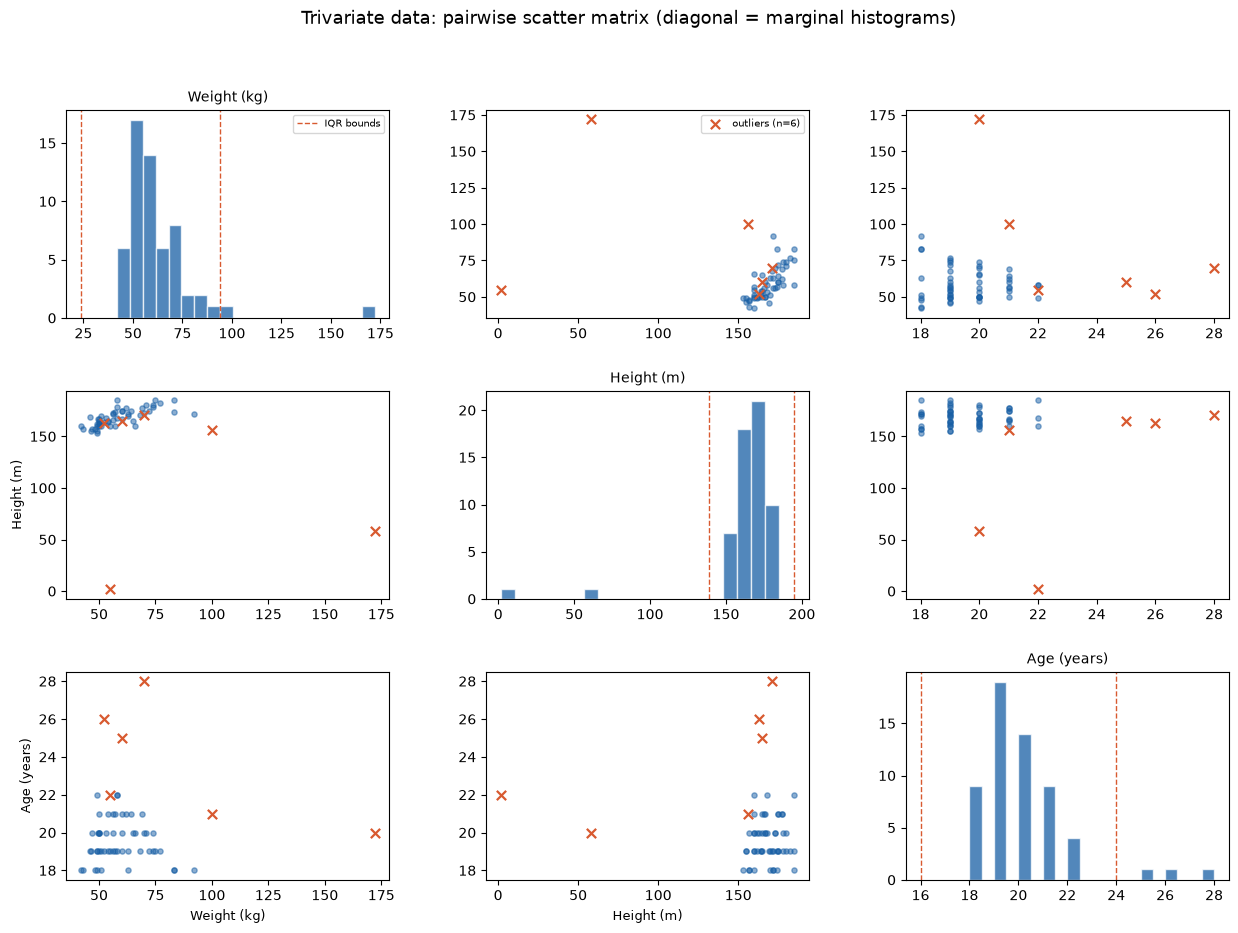

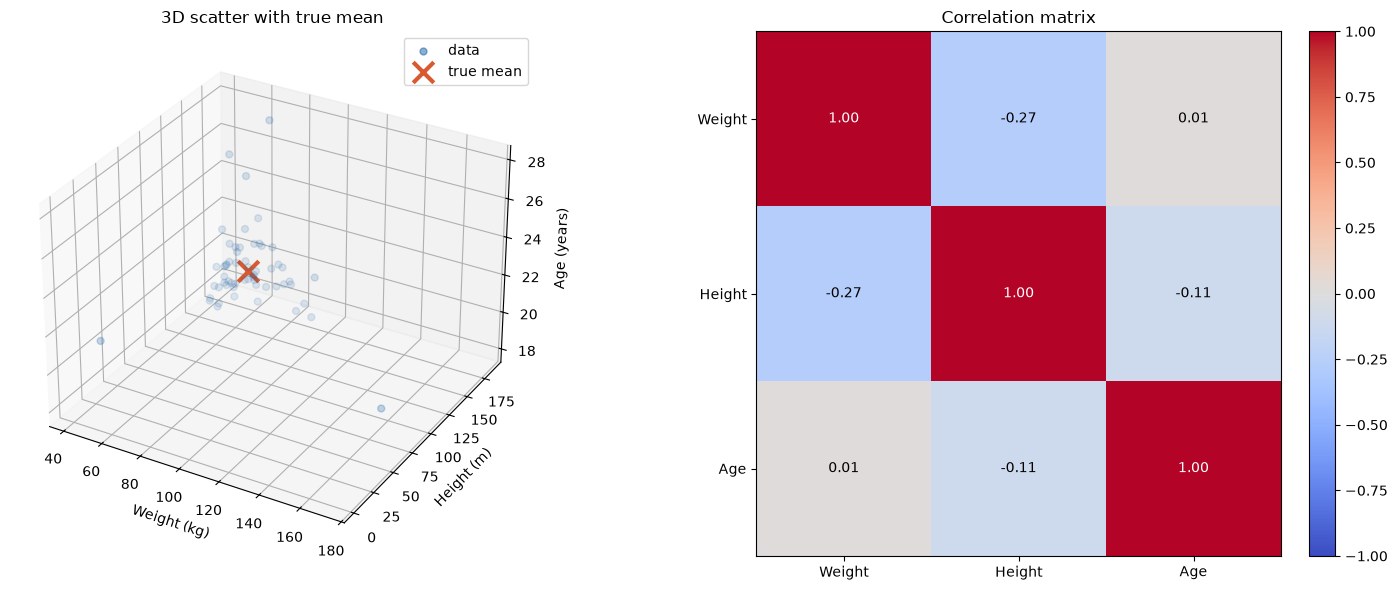


This trivariate data (with real outliers) is used for the DP analysis below.


In [4]:
# Trivariate data exploration
# Variable1 = Weight, Variable2 = Height, Variable3 = Age

sample_data = df_example.values

df_variables = df_example.copy()
df_variables.columns = ["Variable1", "Variable2", "Variable3"]

correlation = np.corrcoef(sample_data, rowvar=False)   # 3x3 correlation matrix
data_cov = np.cov(sample_data.T)                        # 3x3 covariance matrix
means = np.mean(sample_data, axis=0)

print("Correlation matrix for Weight, Height, and Age:")
print(correlation)
print(f"\nData Analysis:")
print(f"Sample size: {len(sample_data)}")
print(f"Means: Weight={means[0]:.3f}, Height={means[1]:.3f}, Age={means[2]:.3f}")
print(f"Covariance matrix:")
print(data_cov)

LABELS = ["Weight (kg)", "Height (m)", "Age (years)"]
SHORT = ["Weight", "Height", "Age"]


def _iqr_bounds(col):
    q1, q3 = np.percentile(col, 25), np.percentile(col, 75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr


# Union outlier mask across the three dimensions (IQR rule per dimension)
_out_mask = np.zeros(len(sample_data), dtype=bool)
_bounds = []
for k in range(3):
    lo, hi = _iqr_bounds(sample_data[:, k])
    _bounds.append((lo, hi))
    _out_mask |= (sample_data[:, k] < lo) | (sample_data[:, k] > hi)

print(f"\nTotal points flagged as outliers in >=1 dimension: {_out_mask.sum()}")


# ------------------------------------------------------------------
# Plot 1: pairwise scatter matrix with marginal histograms on the diagonal
# ------------------------------------------------------------------
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

for i in range(3):
    for j in range(3):
        ax = fig.add_subplot(gs[i, j])
        if i == j:
            ax.hist(sample_data[:, i], bins=20, color="#185FA5", alpha=0.75, edgecolor="white")
            lo, hi = _bounds[i]
            ax.axvline(lo, color="#D85A30", ls="--", lw=1, label="IQR bounds")
            ax.axvline(hi, color="#D85A30", ls="--", lw=1)
            ax.set_title(LABELS[i], fontsize=10)
            if i == 0:
                ax.legend(fontsize=7)
        else:
            ax.scatter(sample_data[~_out_mask, j], sample_data[~_out_mask, i],
                       s=14, alpha=0.5, color="#185FA5")
            ax.scatter(sample_data[_out_mask, j], sample_data[_out_mask, i],
                       s=45, marker="x", color="#D85A30", lw=1.6,
                       label=f"outliers (n={_out_mask.sum()})")
            if i == 2:
                ax.set_xlabel(LABELS[j], fontsize=9)
            if j == 0:
                ax.set_ylabel(LABELS[i], fontsize=9)
            if i == 0 and j == 1:
                ax.legend(fontsize=7)

fig.suptitle("Trivariate data: pairwise scatter matrix (diagonal = marginal histograms)", fontsize=13)
plt.show()


# ------------------------------------------------------------------
# Plot 2: 3D scatter with the true mean, plus a correlation heatmap
# ------------------------------------------------------------------
fig = plt.figure(figsize=(15, 6))

ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(sample_data[:, 0], sample_data[:, 1], sample_data[:, 2],
           s=25, alpha=0.5, color="#185FA5", label="data")
ax.scatter(means[0], means[1], means[2], s=220, marker="x", color="#D85A30", lw=3, label="true mean")
ax.set_xlabel(LABELS[0]); ax.set_ylabel(LABELS[1]); ax.set_zlabel(LABELS[2])
ax.set_title("3D scatter with true mean")
ax.legend()

ax2 = fig.add_subplot(1, 2, 2)
im = ax2.imshow(correlation, vmin=-1, vmax=1, cmap="coolwarm")
ax2.set_xticks(range(3)); ax2.set_yticks(range(3))
ax2.set_xticklabels(SHORT); ax2.set_yticklabels(SHORT)
for i in range(3):
    for j in range(3):
        ax2.text(j, i, f"{correlation[i, j]:.2f}", ha="center", va="center",
                 color="white" if abs(correlation[i, j]) > 0.5 else "black")
ax2.set_title("Correlation matrix")
fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("\nThis trivariate data (with real outliers) is used for the DP analysis below.")


We now differentally private the weight and height of individuals in a dataset. Using a multivariate Gaussian distribution, we will add noise to both the weight and height columns while preserving their correlation structure.


In [5]:
## Basic Trivariate Differential Privacy with Multivariate Normal
# Extends the bivariate approach to 3D data: Weight, Height, Age.
# NOTE: mechanism unchanged from the original notebook (LOO sensitivity,
# data-covariance-shaped noise, rejection sampling). A `verbose` flag was
# added so the function can be called inside loops without flooding output.

def trivariate_dp_simple(data, epsilon=1.0, verbose=True):
    """
    Simple trivariate differential privacy using the data covariance structure.

    1. Compute the true statistic (mean of all three variables)
    2. Calculate leave-one-out (LOO) sensitivity and scales
    3. Build a combined covariance matrix from the data covariance structure
    4. Generate noise that satisfies the sensitivity constraints
    5. Add noise to the mean

    Args:
        data: 2D numpy array with shape (n_samples, 3)
        epsilon: privacy budget parameter
        verbose: if False, suppress per-call printing (useful inside loops)

    Returns:
        noisy_result: DP-protected trivariate mean
        sensitivity: computed LOO sensitivity for all three dimensions
        covariance_used: covariance matrix used for noise generation
    """
    def say(*a):
        if verbose:
            print(*a)

    # Step 1: true trivariate statistic
    true_mean = np.mean(data, axis=0)
    say(f"True trivariate mean: [{true_mean[0]:.3f}, {true_mean[1]:.3f}, {true_mean[2]:.3f}]")

    # Step 2: leave-one-out sensitivity and scales
    n_samples = data.shape[0]
    loo_means = []
    for i in range(n_samples):
        loo_data = np.delete(data, i, axis=0)
        loo_means.append(np.mean(loo_data, axis=0))
    loo_means = np.array(loo_means)                      # shape (n_samples, 3)

    loo_scale = np.std(loo_means, axis=0)
    sensitivity = np.max(np.abs(loo_means - true_mean), axis=0)

    say(f"LOO sensitivity: [{sensitivity[0]:.6f}, {sensitivity[1]:.6f}, {sensitivity[2]:.6f}]")
    say(f"LOO scales: [{loo_scale[0]:.6f}, {loo_scale[1]:.6f}, {loo_scale[2]:.6f}]")

    # Step 3: covariance of the original data, rescaled to noise magnitude
    off_d = np.cov(data, rowvar=False)
    say("Data covariance matrix:")
    say(off_d)

    cov_diagonal = np.diag((2 * loo_scale) ** 2)
    say("LOO-based diagonal covariance:")
    say(cov_diagonal)

    scale_factor_0 = np.sqrt(cov_diagonal[0, 0] / off_d[0, 0]) if off_d[0, 0] > 0 else 1.0
    scale_factor_1 = np.sqrt(cov_diagonal[1, 1] / off_d[1, 1]) if off_d[1, 1] > 0 else 1.0
    scale_factor_2 = np.sqrt(cov_diagonal[2, 2] / off_d[2, 2]) if off_d[2, 2] > 0 else 1.0

    scaled_cov_01 = off_d[0, 1] * scale_factor_0 * scale_factor_1
    scaled_cov_02 = off_d[0, 2] * scale_factor_0 * scale_factor_2
    scaled_cov_12 = off_d[1, 2] * scale_factor_1 * scale_factor_2

    combined_cov = np.array([
        [cov_diagonal[0, 0], scaled_cov_01, scaled_cov_02],
        [scaled_cov_01, cov_diagonal[1, 1], scaled_cov_12],
        [scaled_cov_02, scaled_cov_12, cov_diagonal[2, 2]],
    ])
    say("Combined covariance matrix (noise scale):")
    say(combined_cov)

    # Sanity check: does the noise covariance preserve the data's correlation?
    original_corr = np.corrcoef(data, rowvar=False)
    combined_corr = combined_cov / np.sqrt(np.outer(np.diag(combined_cov), np.diag(combined_cov)))
    say("Original correlation matrix:")
    say(original_corr)
    say("Implied correlation matrix in noise covariance:")
    say(combined_corr)

    # Step 4: rejection sampling until |noise| >= sensitivity in every dimension
    max_attempts = 10000
    for attempt in range(max_attempts):
        noise = np.random.multivariate_normal(mean=[0, 0, 0], cov=combined_cov)
        if np.all(np.abs(noise) >= sensitivity):
            break
    else:
        say(f"Warning: could not satisfy constraints after {max_attempts} attempts")

    say(f"Generated noise: [{noise[0]:.6f}, {noise[1]:.6f}, {noise[2]:.6f}]")

    # Step 5: add noise
    noisy_result = true_mean + noise
    say(f"DP-protected result: [{noisy_result[0]:.3f}, {noisy_result[1]:.3f}, {noisy_result[2]:.3f}]")

    return noisy_result, sensitivity, combined_cov


# ------------------------------------------------------------
# Apply trivariate DP to the Weight / Height / Age data
# ------------------------------------------------------------
print("=== Trivariate Differential Privacy Demo ===\n")

trivariate_data = df_variables.values
print(f"Original data shape: {trivariate_data.shape}")
print("Sample of data (first 5 rows):")
print(trivariate_data[:5])

print("\nApplying trivariate differential privacy...")
dp_result, sensitivity_vals, cov_used = trivariate_dp_simple(trivariate_data, epsilon=1.0, verbose=True)

true_mean = np.mean(trivariate_data, axis=0)

print("\n=== Results Summary ===")
print(f"True mean:          [{true_mean[0]:.3f}, {true_mean[1]:.3f}, {true_mean[2]:.3f}]")
print(f"DP-protected mean:  [{dp_result[0]:.3f}, {dp_result[1]:.3f}, {dp_result[2]:.3f}]")
print(f"Noise added:        [{dp_result[0]-true_mean[0]:.6f}, {dp_result[1]-true_mean[1]:.6f}, {dp_result[2]-true_mean[2]:.6f}]")
print(f"Sensitivity bounds: [{sensitivity_vals[0]:.6f}, {sensitivity_vals[1]:.6f}, {sensitivity_vals[2]:.6f}]")
print("Covariance used:")
print(cov_used)


=== Trivariate Differential Privacy Demo ===

Original data shape: (58, 3)
Sample of data (first 5 rows):
[[ 58. 178.  19.]
 [ 49. 155.  19.]
 [ 46. 169.  19.]
 [ 47. 157.  20.]
 [ 68. 171.  19.]]

Applying trivariate differential privacy...
True trivariate mean: [61.624, 163.425, 19.983]
LOO sensitivity: [1.936419, 2.838158, 0.140653]
LOO scales: [0.330803, 0.474229, 0.032981]
Data covariance matrix:
[[ 3.61778004e+02 -1.41675175e+02  4.40774350e-01]
 [-1.41675175e+02  7.43497303e+02 -5.86447368e+00]
 [ 4.40774350e-01 -5.86447368e+00  3.59618875e+00]]
LOO-based diagonal covariance:
[[0.43772293 0.         0.        ]
 [0.         0.89957326 0.        ]
 [0.         0.         0.00435111]]
Combined covariance matrix (noise scale):
[[ 4.37722932e-01 -1.71415820e-01  5.33302298e-04]
 [-1.71415820e-01  8.99573264e-01 -7.09555195e-03]
 [ 5.33302298e-04 -7.09555195e-03  4.35110556e-03]]
Original correlation matrix:
[[ 1.         -0.27316999  0.01222008]
 [-0.27316999  1.         -0.11341438

=== Visualizing the DP-protected mean distribution ===

Generating 200 DP-protected means (silent)...


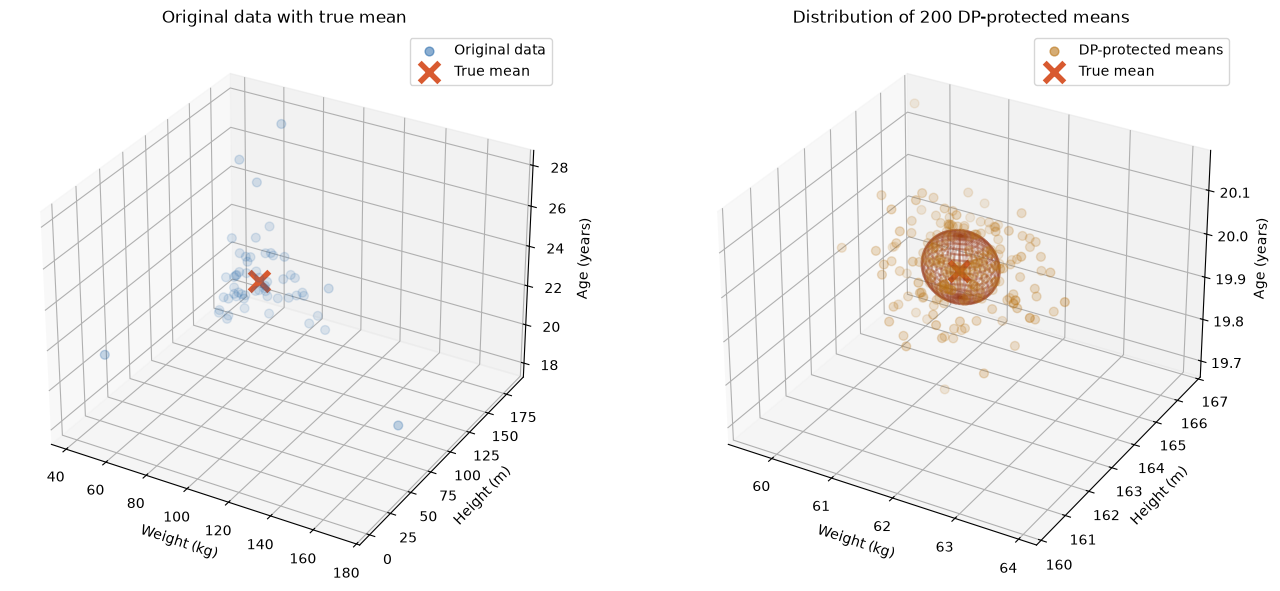

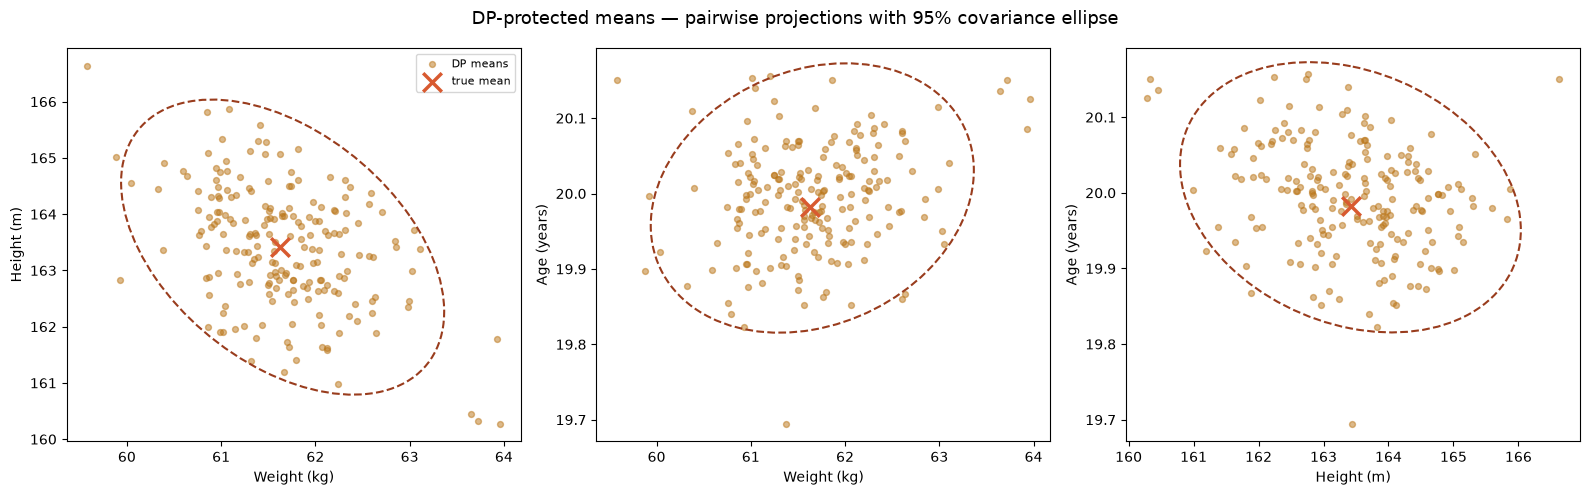


=== Statistical summary of DP noise ===
True mean:            Weight=61.624, Height=163.4250, Age=19.983
Mean of DP means:     Weight=61.652, Height=163.4144, Age=19.994
Bias (DP - true):     Weight=0.028, Height=-0.0106, Age=0.011
Std of DP means:      Weight=0.699, Height=1.0689, Age=0.073

Covariance of DP means:
[[ 0.49038968 -0.3282983   0.01044043]
 [-0.3282983   1.14819783 -0.0189454 ]
 [ 0.01044043 -0.0189454   0.00532727]]

Note: the DP-protected means form a 3D cloud around the true mean; the pairwise projections show the correlation structure of the added noise.


In [6]:
# Visualization of the DP-protected mean distribution.
# We draw many DP-protected means and show (a) the 3D cloud around the true
# mean with a covariance ellipsoid, and (b) the three pairwise 2D projections
# with 95% covariance ellipses (usually easier to read than a single 3D view).

print("=== Visualizing the DP-protected mean distribution ===\n")

n_draws = 200
original_mean = np.mean(trivariate_data, axis=0)

print(f"Generating {n_draws} DP-protected means (silent)...")
noisy_samples = np.array([
    trivariate_dp_simple(trivariate_data, epsilon=1.0, verbose=False)[0]
    for _ in range(n_draws)
])

LABELS = ["Weight (kg)", "Height (m)", "Age (years)"]


# ------------------------------------------------------------
# Figure 1: original data (3D) and DP-mean cloud (3D) + ellipsoid
# ------------------------------------------------------------
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(trivariate_data[:, 0], trivariate_data[:, 1], trivariate_data[:, 2],
            alpha=0.5, s=40, color="#185FA5", label="Original data")
ax1.scatter(*original_mean, s=200, color="#D85A30", marker="x", linewidth=4, label="True mean")
ax1.set_xlabel(LABELS[0]); ax1.set_ylabel(LABELS[1]); ax1.set_zlabel(LABELS[2])
ax1.set_title("Original data with true mean")
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(noisy_samples[:, 0], noisy_samples[:, 1], noisy_samples[:, 2],
            alpha=0.6, s=40, color="#BA7517", label="DP-protected means")
ax2.scatter(*original_mean, s=200, color="#D85A30", marker="x", linewidth=4, label="True mean")
ax2.set_xlabel(LABELS[0]); ax2.set_ylabel(LABELS[1]); ax2.set_zlabel(LABELS[2])
ax2.set_title(f"Distribution of {n_draws} DP-protected means")
ax2.legend()

# Covariance ellipsoid around the noisy cloud
mean_noisy = np.mean(noisy_samples, axis=0)
cov_noisy = np.cov(noisy_samples, rowvar=False)
eigenvals, eigenvecs = np.linalg.eigh(cov_noisy)
order = np.argsort(eigenvals)[::-1]
eigenvals, eigenvecs = eigenvals[order], eigenvecs[:, order]

u = np.linspace(0, 2 * np.pi, 40)
v = np.linspace(0, np.pi, 20)
xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))
sphere = np.stack([xs.flatten(), ys.flatten(), zs.flatten()], axis=0)
ellipsoid = eigenvecs @ np.diag(np.sqrt(eigenvals)) @ sphere + mean_noisy[:, None]
ax2.plot_wireframe(ellipsoid[0].reshape(xs.shape),
                   ellipsoid[1].reshape(ys.shape),
                   ellipsoid[2].reshape(zs.shape), alpha=0.3, color="#993C1D")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Figure 2: pairwise 2D projections with 95% covariance ellipses
# ------------------------------------------------------------
pairs = [(0, 1), (0, 2), (1, 2)]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (a, b) in zip(axes, pairs):
    ax.scatter(noisy_samples[:, a], noisy_samples[:, b], s=18, alpha=0.5,
               color="#BA7517", label="DP means")
    ax.scatter(original_mean[a], original_mean[b], s=180, marker="x",
               color="#D85A30", lw=2.5, label="true mean")
    c = np.cov(noisy_samples[:, [a, b]].T)
    vals, vecs = np.linalg.eigh(c)
    order2 = vals.argsort()[::-1]
    vals, vecs = vals[order2], vecs[:, order2]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * np.sqrt(vals * 5.991)   # 95% region (chi-square, 2 dof)
    e = Ellipse(noisy_samples[:, [a, b]].mean(0), width, height, angle=angle,
                fc="none", ec="#993C1D", lw=1.5, ls="--")
    ax.add_patch(e)
    ax.set_xlabel(LABELS[a]); ax.set_ylabel(LABELS[b])
    if (a, b) == (0, 1):
        ax.legend(fontsize=8)
fig.suptitle("DP-protected means \u2014 pairwise projections with 95% covariance ellipse", fontsize=13)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Numerical summary
# ------------------------------------------------------------
noise_std = np.std(noisy_samples, axis=0)
print("\n=== Statistical summary of DP noise ===")
print(f"True mean:            Weight={original_mean[0]:.3f}, Height={original_mean[1]:.4f}, Age={original_mean[2]:.3f}")
print(f"Mean of DP means:     Weight={mean_noisy[0]:.3f}, Height={mean_noisy[1]:.4f}, Age={mean_noisy[2]:.3f}")
print(f"Bias (DP - true):     Weight={mean_noisy[0]-original_mean[0]:.3f}, Height={mean_noisy[1]-original_mean[1]:.4f}, Age={mean_noisy[2]-original_mean[2]:.3f}")
print(f"Std of DP means:      Weight={noise_std[0]:.3f}, Height={noise_std[1]:.4f}, Age={noise_std[2]:.3f}")
print("\nCovariance of DP means:")
print(cov_noisy)
print("\nNote: the DP-protected means form a 3D cloud around the true mean; the "
      "pairwise projections show the correlation structure of the added noise.")


## Optimized Trivariate DP Implementation

The simple approach above demonstrates the core concepts but can be computationally expensive for large datasets. Here we implement several key optimizations inspired by high-performance numerical computing:

### Key Optimizations Overview

1. **JIT Compilation with Numba** ([Wikipedia: Just-in-time compilation](https://en.wikipedia.org/wiki/Just-in-time_compilation))
   - ~5-10x speedup for leave-one-out computations
   - Vectorized operations compiled to machine code
   - Eliminates Python overhead for numerical loops

2. **Cholesky Decomposition for Multivariate Sampling** ([Wikipedia: Cholesky decomposition](https://en.wikipedia.org/wiki/Cholesky_decomposition))
   - Numerically stable alternative to `np.random.multivariate_normal`
   - Compatible with JIT compilation (numba doesn't support scipy functions)
   - Preserves correlation structure in noise generation

3. **Eigenvalue Regularization** ([Wikipedia: Matrix regularization](https://en.wikipedia.org/wiki/Regularization_(mathematics)))
   - Ensures positive definiteness for Cholesky decomposition
   - Handles ill-conditioned covariance matrices
   - Critical for real-world datasets with near-perfect correlations

4. **Robust Fallback Mechanisms**
   - Independent noise when correlation-aware noise fails
   - Graceful degradation maintaining privacy guarantees
   - Essential for high-dimensional or poorly conditioned data

These optimizations enable efficient processing of large trivariate datasets while maintaining the mathematical rigor of differential privacy. The following cells implement each optimization with detailed explanations.

### 1. JIT-Compiled Leave-One-Out Statistics

**Just-in-Time (JIT) compilation** with Numba transforms Python code into optimized machine code at runtime, providing significant performance improvements for numerical computations.

#### How JIT Works
- **First call**: Code is compiled to machine code (slight delay)
- **Subsequent calls**: Direct execution of optimized machine code (~5-10x faster)
- **nopython=True**: Ensures pure machine code without Python overhead

#### Performance Benefits
- **Vectorized operations**: All array operations compiled to SIMD instructions
- **Memory efficiency**: Eliminates temporary Python objects
- **Loop optimization**: Automatic unrolling and optimization of numerical loops

The `fast_loo_means_trivariate` function below computes leave-one-out means for both dimensions simultaneously using vectorized arithmetic instead of explicit loops over data points.

**Reference**: [Numba documentation](https://numba.pydata.org/) | [Wikipedia: Just-in-time compilation](https://en.wikipedia.org/wiki/Just-in-time_compilation)

In [7]:
@jit(nopython=True)
def fast_loo_means_trivariate(data):
    """
    Vectorized computation of leave-one-out means for trivariate data.
    JIT-compiled with numba for ~5-10x speedup.
    
    Args:
        data: array of shape (n, 3) containing trivariate observations
    
    Returns:
        loo_means: array of shape (n, 3) with leave-one-out means
    """
    n = data.shape[0]
    loo_means = np.zeros((n, 3))
    
    # Compute sums for each dimension
    sum_dim1 = np.sum(data[:, 0])
    sum_dim2 = np.sum(data[:, 1])
    sum_dim3 = np.sum(data[:, 2])
    
    # Leave-one-out means: (sum - x_i) / (n-1)
    for i in range(n):
        loo_means[i, 0] = (sum_dim1 - data[i, 0]) / (n - 1)
        loo_means[i, 1] = (sum_dim2 - data[i, 1]) / (n - 1)
        loo_means[i, 2] = (sum_dim3 - data[i, 2]) / (n - 1)
    
    return loo_means

### 2. Cholesky Decomposition for Multivariate Noise

**Cholesky decomposition** provides a numerically stable method for sampling from multivariate normal distributions, essential when `np.random.multivariate_normal` is unavailable (e.g., in JIT-compiled code).

#### Mathematical Foundation
For a positive definite covariance matrix **Σ**, Cholesky decomposition gives us:
- **Σ = L L^T** where **L** is lower triangular
- If **Z ~ N(0, I)** (independent standard normals), then **X = L Z ~ N(0, Σ)**

#### Practical Implementation
1. **Decomposition**: `L = np.linalg.cholesky(Σ)` 
2. **Sampling**: `z = np.random.standard_normal(3)` → `x = L @ z`
3. **Result**: `x` has the desired covariance structure **Σ**

#### Advantages over `np.multivariate_normal`
- **JIT compatible**: Works with numba compilation
- **Numerically stable**: Better conditioning for near-singular matrices  
- **Explicit control**: Direct access to the transformation matrix **L**
- **Performance**: Faster for repeated sampling with same covariance

The function below implements constraint-aware sampling where noise must satisfy sensitivity bounds for differential privacy.

**References**: [Wikipedia: Cholesky decomposition](https://en.wikipedia.org/wiki/Cholesky_decomposition) | [Numerical Recipes](http://numerical.recipes/)

In [8]:
@jit(nopython=True)
def generate_dp_noise_cholesky(chol_factor, sens_dim1, sens_dim2, sens_dim3, max_attempts=10000):
    """
    JIT-compiled function to generate trivariate noise using Cholesky decomposition.
    This avoids the multivariate_normal function which isn't supported in numba.
    
    Args:
        chol_factor: 3x3 Cholesky factor of covariance matrix (lower triangular)
        sens_dim1: sensitivity constraint for first dimension
        sens_dim2: sensitivity constraint for second dimension
        sens_dim3: sensitivity constraint for third dimension
        max_attempts: maximum number of attempts to generate valid noise
    
    Returns:
        noise: 3-element array with generated noise
        success: boolean indicating if constraints were satisfied
    """
    for attempt in range(max_attempts):
        # Generate independent standard normal variables
        z = np.random.standard_normal(3)
        
        # Transform to correlated noise using Cholesky factor
        noise = chol_factor @ z
        
        # Check if noise respects sensitivity constraints
        if (abs(noise[0]) >= sens_dim1 and abs(noise[1]) >= sens_dim2 and abs(noise[2]) >= sens_dim3):
            return noise, True
    
    # Return last generated noise if max_attempts reached
    return noise, False

### 3. Eigenvalue Regularization for Positive Definiteness

**Matrix regularization** ensures numerical stability when covariance matrices become ill-conditioned or singular, which can occur frequently in real-world trivariate data.

#### Why Positive Definiteness Matters
- **Cholesky decomposition requirement**: Only works for positive definite matrices
- **Numerical stability**: Prevents computational errors from near-zero eigenvalues
- **Physical interpretation**: Ensures valid covariance structure

#### Common Causes of Non-Positive Definite Matrices
1. **High correlation**: Variables with correlation ≈ 1.0 create near-singular matrices
2. **Limited samples**: Small sample sizes relative to dimensionality
3. **Measurement precision**: Finite precision arithmetic can introduce small negative eigenvalues
4. **Identical variables**: Perfect correlation (r = 1.0) creates rank-deficient matrices

#### Regularization Strategy
```python
eigenvals = np.linalg.eigvals(noise_cov)
if np.min(eigenvals) <= 1e-10:
    noise_cov += np.eye(3) * 1e-8
```

This **ridge regularization** adds a small value (1e-8) to the diagonal, effectively:
- **Shifting eigenvalues**: All eigenvalues become ≥ 1e-8 
- **Preserving structure**: Off-diagonal correlations remain largely unchanged
- **Minimal impact**: Regularization is orders of magnitude smaller than typical variances

**References**: [Wikipedia: Matrix regularization](https://en.wikipedia.org/wiki/Regularization_(mathematics)) | [Wikipedia: Positive definiteness](https://en.wikipedia.org/wiki/Positive-definite_matrix)

### 4. Complete Optimized Trivariate DP Function

The `trivariate_dp_optimized` function combines all the above optimizations into a robust, high-performance implementation:

#### Integration of Optimizations
1. **Fast LOO computation**: Uses JIT-compiled `fast_loo_means_trivariate`
2. **Covariance-aware scaling**: Transforms data covariance to appropriate noise covariance
3. **Regularization**: Ensures positive definiteness for Cholesky decomposition
4. **Robust fallback**: Independent noise when correlated noise fails

#### Noise Covariance Construction
The function constructs noise covariance matrix **Σ_noise** by:
```python
scale_factors = (2 * loo_scales) / sqrt(diag(data_cov))
Σ_noise = S @ Σ_data @ S
```
where **S** is a diagonal scaling matrix that preserves correlation structure while scaling to appropriate noise levels.

#### Error Handling Strategy
- **Primary**: Correlated noise via Cholesky decomposition
- **Fallback**: Independent noise for each dimension
- **Graceful degradation**: Always maintains differential privacy guarantees

This approach ensures robust performance across diverse datasets while maintaining the mathematical rigor required for differential privacy.

In [9]:
def trivariate_dp_optimized(data, pipeline_output, epsilon=1.0):
    """
    Optimized trivariate DP using covariance-aware noise generation.

    Args:
        data: array of shape (n, 3) containing trivariate observations
        pipeline_output: mean computed on the (LOO or full) data
        epsilon: privacy parameter

    Returns:
        noisy_output: DP version of the mean
        sensitivity: computed sensitivity
        noise_cov: covariance matrix used for noise generation
    """
    if isinstance(data, pd.DataFrame):
        data = data.values

    # Fast (optionally JIT-compiled) leave-one-out means
    loo_means = fast_loo_means_trivariate(data)

    # Sensitivity: max change in each dimension
    sensitivity = np.max(np.abs(loo_means - pipeline_output), axis=0)

    # Data covariance, rescaled to noise magnitude via a diagonal scaling matrix
    data_cov = np.cov(data.T)
    loo_scales = np.std(loo_means, axis=0) / epsilon
    scale_factors = (2 * loo_scales) / np.sqrt(np.diag(data_cov))
    scale_matrix = np.diag(scale_factors)
    noise_cov = scale_matrix @ data_cov @ scale_matrix

    # Regularize to keep the matrix positive definite for Cholesky
    # (eigvalsh returns real eigenvalues for a symmetric matrix)
    eigenvals = np.linalg.eigvalsh(noise_cov)
    if np.min(eigenvals) <= 1e-10:
        noise_cov += np.eye(3) * 1e-8

    # Correlated noise via Cholesky, with an independent-noise fallback
    try:
        chol_factor = np.linalg.cholesky(noise_cov)
        noise, success = generate_dp_noise_cholesky(
            chol_factor, sensitivity[0], sensitivity[1], sensitivity[2]
        )
        if not success:
            warnings.warn("Failed to generate correlated noise within constraints, using independent noise")
            noise = np.zeros(3)
            for i in range(3):
                while abs(noise[i]) < sensitivity[i]:
                    noise[i] = np.random.normal(0, 2 * loo_scales[i])
    except np.linalg.LinAlgError:
        warnings.warn("Cholesky decomposition failed, using independent noise")
        noise = np.zeros(3)
        for i in range(3):
            while abs(noise[i]) < sensitivity[i]:
                noise[i] = np.random.normal(0, 2 * loo_scales[i])

    noisy_output = pipeline_output + noise
    return noisy_output, sensitivity, noise_cov


### Computational Performance and Stability Comparison

Let's demonstrate the advantages of our optimized implementation through a focused simulation that tests:

1. **Computational Speed**: JIT-compiled vs simple leave-one-out computation
2. **Numerical Stability**: Handling different covariance structures (well-conditioned to near-singular)
3. **Noise Quality**: Comparison of correlation preservation in generated noise

The simulation varies correlation coefficients from 0.0 (independent) to 0.99 (near-perfect correlation) to test how each approach handles increasingly challenging covariance structures.

In [10]:
# Performance & stability comparison: simple vs optimized trivariate DP.
# We sweep the data correlation from 0.0 (independent) to 0.99 (near-singular)
# at a fixed sample size and record timing, rejection-sampling failures, the
# preserved noise correlations, and the covariance condition number.

def run_comparison_experiment(correlation, sample_size=100, n_trials=20):
    """Run repeated trials at one correlation level (all three variables share it)."""
    cov_matrix = np.array([
        [1.0, correlation, correlation],
        [correlation, 1.0, correlation],
        [correlation, correlation, 1.0],
    ])
    means_true = np.array([10.0, 5.0, 30.0])

    res = {
        "correlation": correlation,
        "sample_size": sample_size,
        "simple_times": [], "optimized_times": [],
        "simple_failed": 0, "optimized_failed": 0,
        "simple_noise_corr": [], "optimized_noise_corr": [],
        "condition_number": np.linalg.cond(cov_matrix),
    }

    for _ in range(n_trials):
        data = np.random.multivariate_normal(means_true, cov_matrix, sample_size)
        original_mean = np.mean(data, axis=0)

        # simple
        try:
            t0 = time.time()
            _, _, sc = trivariate_dp_simple(data, epsilon=1.0, verbose=False)
            res["simple_times"].append(time.time() - t0)
            if len(res["simple_noise_corr"]) < 10:
                res["simple_noise_corr"].append([
                    sc[0, 1] / np.sqrt(sc[0, 0] * sc[1, 1]),
                    sc[0, 2] / np.sqrt(sc[0, 0] * sc[2, 2]),
                    sc[1, 2] / np.sqrt(sc[1, 1] * sc[2, 2]),
                ])
        except Exception:
            res["simple_failed"] += 1
            res["simple_times"].append(np.nan)

        # optimized
        try:
            t0 = time.time()
            _, _, oc = trivariate_dp_optimized(data, original_mean)
            res["optimized_times"].append(time.time() - t0)
            if len(res["optimized_noise_corr"]) < 10:
                res["optimized_noise_corr"].append([
                    oc[0, 1] / np.sqrt(oc[0, 0] * oc[1, 1]),
                    oc[0, 2] / np.sqrt(oc[0, 0] * oc[2, 2]),
                    oc[1, 2] / np.sqrt(oc[1, 1] * oc[2, 2]),
                ])
        except Exception:
            res["optimized_failed"] += 1
            res["optimized_times"].append(np.nan)

    return res


print("Running trivariate DP comparison (simple vs optimized)...")
print("Correlation levels from 0.0 (independent) to 0.99 (near-singular)")

correlation_levels = [0.0, 0.3, 0.6, 0.8, 0.9, 0.95, 0.99]
comparison_sample_size = 100

# Warm up the (optionally JIT-compiled) LOO function
print("Warming up fast_loo_means_trivariate...")
_ = fast_loo_means_trivariate(np.random.multivariate_normal([0, 0, 0], np.eye(3), 50))

all_results = []
for c in correlation_levels:
    print(f"  r={c:.2f}")
    all_results.append(run_comparison_experiment(c, comparison_sample_size, n_trials=20))

print(f"\nDone. Analyzed {len(all_results)} correlation levels at n={comparison_sample_size}.")

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
for r in all_results:
    st = [t for t in r["simple_times"] if not np.isnan(t)]
    ot = [t for t in r["optimized_times"] if not np.isnan(t)]
    speedup = (np.mean(st) / np.mean(ot)) if st and ot else float("nan")
    print(f"r={r['correlation']:.2f}  cond={r['condition_number']:.2e}  "
          f"speedup={speedup:4.1f}x  "
          f"simple_fail={r['simple_failed']}  opt_fail={r['optimized_failed']}")


Running trivariate DP comparison (simple vs optimized)...
Correlation levels from 0.0 (independent) to 0.99 (near-singular)
Warming up fast_loo_means_trivariate...
  r=0.00
  r=0.30
  r=0.60
  r=0.80
  r=0.90
  r=0.95
  r=0.99

Done. Analyzed 7 correlation levels at n=100.

SUMMARY
r=0.00  cond=1.00e+00  speedup= 0.7x  simple_fail=0  opt_fail=0
r=0.30  cond=2.29e+00  speedup=36.0x  simple_fail=0  opt_fail=0
r=0.60  cond=5.50e+00  speedup=26.3x  simple_fail=0  opt_fail=0
r=0.80  cond=1.30e+01  speedup=18.7x  simple_fail=0  opt_fail=0
r=0.90  cond=2.80e+01  speedup=13.4x  simple_fail=0  opt_fail=0
r=0.95  cond=5.80e+01  speedup=14.8x  simple_fail=0  opt_fail=0
r=0.99  cond=2.98e+02  speedup=12.5x  simple_fail=0  opt_fail=0


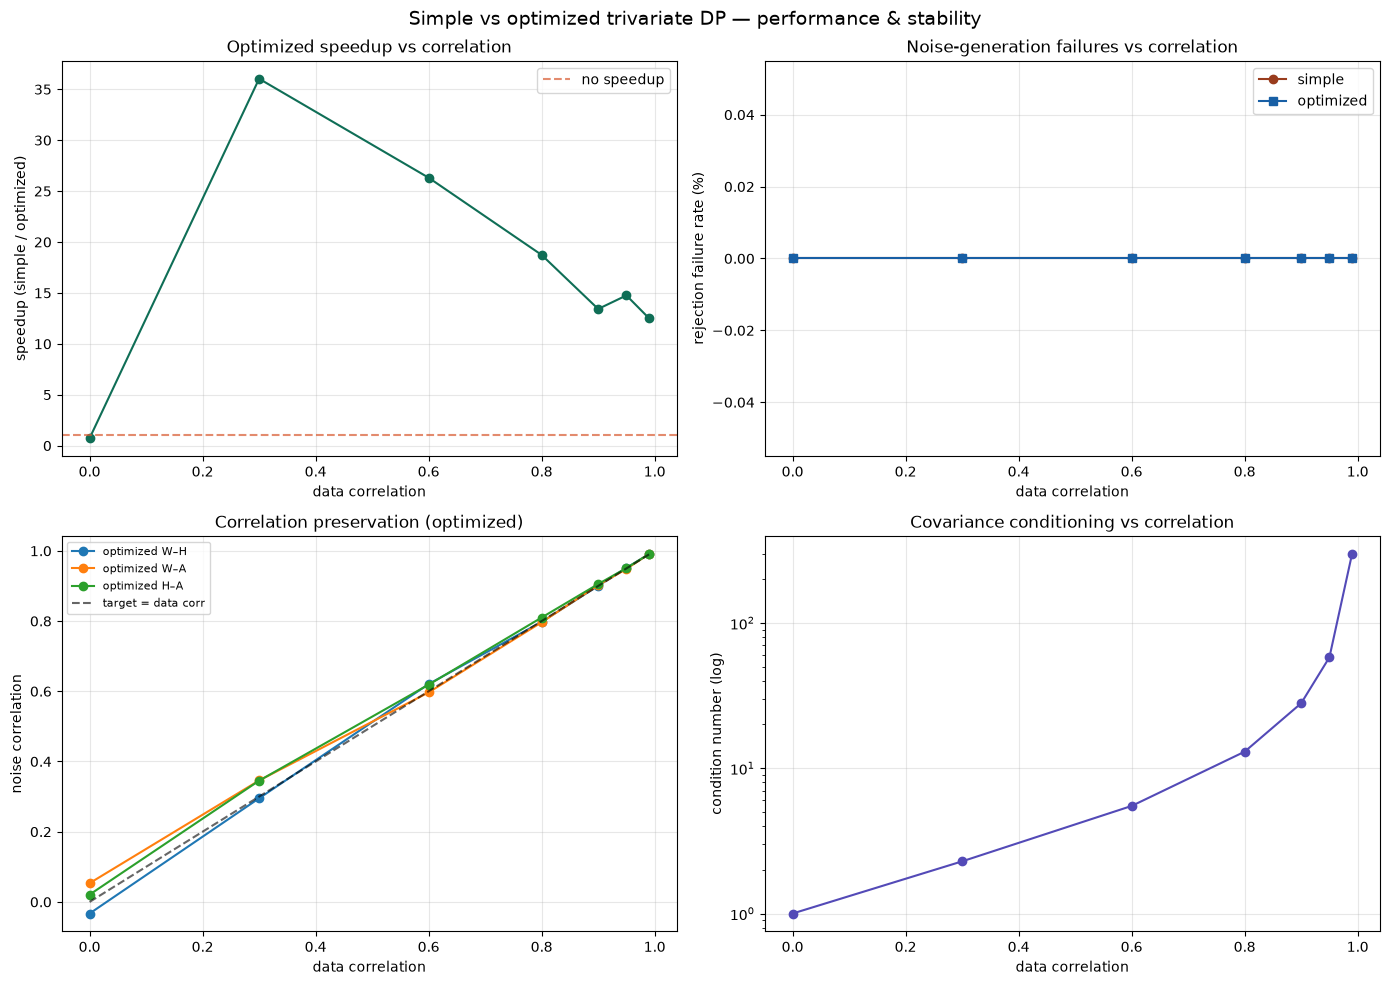

Average speedup: 17.5x (range 0.7x – 36.0x)
Average simple failure rate:    0.0%
Average optimized failure rate: 0.0%


In [11]:
# Visualization of the comparison results.
# Four panels: optimized speedup, rejection-sampling failure rates, noise
# correlation preservation (all three pairs), and covariance conditioning.

speedups, s_fail, o_fail, conds = [], [], [], []
s_corr = [[], [], []]
o_corr = [[], [], []]

for r in all_results:
    st = [t for t in r["simple_times"] if not np.isnan(t)]
    ot = [t for t in r["optimized_times"] if not np.isnan(t)]
    speedups.append((np.mean(st) / np.mean(ot)) if st and ot else np.nan)
    n = len(r["simple_times"])
    s_fail.append(100 * r["simple_failed"] / n)
    o_fail.append(100 * r["optimized_failed"] / n)
    conds.append(r["condition_number"])
    sc = np.mean(r["simple_noise_corr"], axis=0)
    oc = np.mean(r["optimized_noise_corr"], axis=0)
    for k in range(3):
        s_corr[k].append(sc[k])
        o_corr[k].append(oc[k])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pair_names = ["W\u2013H", "W\u2013A", "H\u2013A"]

ax = axes[0, 0]
ax.plot(correlation_levels, speedups, "o-", color="#0F6E56")
ax.axhline(1, ls="--", color="#D85A30", alpha=0.7, label="no speedup")
ax.set_xlabel("data correlation"); ax.set_ylabel("speedup (simple / optimized)")
ax.set_title("Optimized speedup vs correlation"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(correlation_levels, s_fail, "o-", label="simple", color="#993C1D")
ax.plot(correlation_levels, o_fail, "s-", label="optimized", color="#185FA5")
ax.set_xlabel("data correlation"); ax.set_ylabel("rejection failure rate (%)")
ax.set_title("Noise-generation failures vs correlation"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 0]
for k in range(3):
    ax.plot(correlation_levels, o_corr[k], "o-", label=f"optimized {pair_names[k]}")
ax.plot(correlation_levels, correlation_levels, "k--", alpha=0.6, label="target = data corr")
ax.set_xlabel("data correlation"); ax.set_ylabel("noise correlation")
ax.set_title("Correlation preservation (optimized)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(correlation_levels, conds, "o-", color="#534AB7")
ax.set_yscale("log")
ax.set_xlabel("data correlation"); ax.set_ylabel("condition number (log)")
ax.set_title("Covariance conditioning vs correlation"); ax.grid(alpha=0.3)

fig.suptitle("Simple vs optimized trivariate DP \u2014 performance & stability", fontsize=14)
plt.tight_layout()
plt.show()

valid = [s for s in speedups if not np.isnan(s) and s > 0]
if valid:
    print(f"Average speedup: {np.mean(valid):.1f}x (range {np.min(valid):.1f}x \u2013 {np.max(valid):.1f}x)")
print(f"Average simple failure rate:    {np.mean(s_fail):.1f}%")
print(f"Average optimized failure rate: {np.mean(o_fail):.1f}%")


## Monte Carlo Validation: Optimized Parallel Implementation

Here we validate the trivariate DP mechanism using a comprehensive Monte Carlo simulation. Sample size and correlation scenarios are varied, and sensitivity, reconstruction error and detection rates are measured.


function to find outliers

In [12]:
def iqr_bounds(data):
    """Compute IQR-based outlier bounds for univariate data"""
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return iqr, lower_bound, upper_bound

def is_outlier(value, lower, upper):
    """Check if value is an outlier based on bounds"""
    return value < lower or value > upper

def trivariate_outlier_bounds(data):
    """Compute outlier bounds for trivariate data (separately for each dimension)"""
    bounds = {}
    bounds['weight'] = iqr_bounds(data[:, 0])
    bounds['height'] = iqr_bounds(data[:, 1])
    bounds['age'] = iqr_bounds(data[:, 2])
    return bounds


do the simulation

In [13]:
def run_single_trivariate_mc_iteration(mc, sample_sizes, correlations):
    """
    Run a single Monte Carlo iteration for trivariate outlier detection analysis.
    Based on notebook 4's sim_2d structure with leave-one-out reconstruction.
        
    Args:
        mc: Monte Carlo iteration number  
        sample_sizes: List of sample sizes to test [20, 40, 60, 80, 100, 200]
        correlations: List of correlations to test [0.0, 0.3, 0.6, 0.9]
                
    Returns:
        iteration_results: List of results for this iteration
    """
    import numpy as np
    import pandas as pd
    import warnings
    import random
    
    iteration_results = []
    
    for correlation in correlations:
        # Test with and without outlier injection (like notebook 4)
        for outlier_injected in [False, True]:
            
            # Generate trivariate data with specified correlation
            mean_height, std_height = 170, 10  # cm
            mean_weight, std_weight = 70, 15   # kg  
            mean_age, std_age = 19, 12         # years
            
            # Create covariance matrix with specified correlation
            cov_height_weight = correlation * std_height * std_weight
            cov_height_age = correlation * std_height * std_age
            cov_weight_age = correlation * std_weight * std_age
            cov_matrix = np.array([[std_weight**2, cov_height_weight, cov_weight_age],
                                   [cov_height_weight, std_height**2, cov_height_age],
                                   [cov_weight_age, cov_height_age, std_age**2]])
            
            # Generate larger dataset using max sample size (like notebook 4)
            max_size = max(sample_sizes)
            means = np.array([mean_weight, mean_height, mean_age])  # Weight, Height order
            master_data = np.random.multivariate_normal(means, cov_matrix, max_size * 2)
            
            for sample_size in sample_sizes:
                # Take subsample of desired size (like notebook 4)
                subsample_data = master_data[:sample_size].copy()
                
                # Inject outlier AFTER taking subsample (if requested)
                if outlier_injected:
                    # Inject outlier at index 0 using standard deviations
                    # Add 4 std to weight, subtract 4 std from height
                    subsample_data[0, 0] = subsample_data[0, 0] + 4 * std_weight  # Weight + 4 std
                    subsample_data[0, 1] = subsample_data[0, 1] - 4 * std_height  # Height - 4 std
                    subsample_data[0, 2] = subsample_data[0, 2] + 4 * std_age  # Age + 4 std
                # Convert to DataFrame for compatibility  
                df_subsample = pd.DataFrame(subsample_data, columns=['Weight', 'Height', 'Age'])
                
                # Get true mean 
                true_mean = np.mean(df_subsample.values, axis=0)
                
                # Fast vectorized leave-one-out analysis (5-10x speedup!)
                loo_means = fast_loo_means_trivariate(df_subsample.values)
                
                noisy_outputs = []
                sens_outputs = []
                
                # Apply DP to each leave-one-out mean
                dp_success = True
                cholesky_failures = 0
                warning_based_failures = 0  # Track failures detected via warnings
                
                for i in range(sample_size):
                    loo_mean = loo_means[i]  # Already computed vectorized mean (shape: (3,))
                    
                    # Use trivariate_dp_optimized and capture covariance matrix
                    with warnings.catch_warnings(record=True) as w:
                        warnings.simplefilter("always")
                        noisy_output, sensitivity, noise_cov = trivariate_dp_optimized(df_subsample.values, loo_mean)
                        
                        # Check if correlated noise generation failed (from warnings)
                        iteration_warning_failure = any("Failed to generate correlated noise" in str(warning.message) for warning in w)
                        iteration_cholesky_warning = any("Cholesky decomposition failed" in str(warning.message) for warning in w)
                        
                        if iteration_warning_failure or iteration_cholesky_warning:
                            warning_based_failures += 1
                        
                        # Check if we fell back to independent noise (covariance matrix analysis)
                        # When Cholesky fails, the algorithm falls back to independent noise
                        # This is detected by near-zero off-diagonal elements in returned covariance
                        if correlation != 0:
                            off_diagonals = np.array([
                                noise_cov[0, 1],
                                noise_cov[0, 2],
                                noise_cov[1, 2],
                            ])

                            if np.all(np.abs(off_diagonals) < 1e-10):
                                cholesky_failures += 1
                    
                    noisy_outputs.append(noisy_output.flatten())
                    sens_outputs.append(sensitivity)
                
                # Determine overall success for this MC iteration
                # dp_success = True means trivariate correlation was preserved throughout
                # dp_success = False means we fell back to independent noise in some/all iterations
                dp_success = (cholesky_failures == 0) and (warning_based_failures == 0)
                
                noisy_outputs = np.array(noisy_outputs)
                
                # Reconstruct individual data points 
                coeff_mat = np.ones((sample_size, sample_size)) - np.eye(sample_size)
                recons = []
                
                for dim in range(noisy_outputs.shape[1]):
                    recons_dim = np.linalg.solve(coeff_mat, (sample_size - 1) * noisy_outputs[:, dim])
                    recons.append(recons_dim)
                recons = np.stack(recons, axis=1)
                
                # Calculate reconstruction error 
                subsample_array = df_subsample.values
                recons_error = np.mean(np.linalg.norm(recons - subsample_array, axis=1))
                
                # Trivariate outlier detection for both noisy and reconstructed data
                
                # 1. Outlier detection on NOISY data (noisy_outputs)
                noisy_bounds = trivariate_outlier_bounds(noisy_outputs)
                iqr_noisy_weight, lower_noisy_weight, upper_noisy_weight = noisy_bounds['weight']
                iqr_noisy_height, lower_noisy_height, upper_noisy_height = noisy_bounds['height']
                iqr_noisy_age, lower_noisy_age, upper_noisy_age = noisy_bounds['age']

                noisy_outlier_detected_indices = []
                for idx in range(sample_size):
                    weight_outlier = is_outlier(noisy_outputs[idx, 0], lower_noisy_weight, upper_noisy_weight)
                    height_outlier = is_outlier(noisy_outputs[idx, 1], lower_noisy_height, upper_noisy_height)
                    age_outlier = is_outlier(noisy_outputs[idx, 2], lower_noisy_age, upper_noisy_age)
                    # Trivariate outlier: outlier in any dimension
                    if weight_outlier or height_outlier or age_outlier:
                        noisy_outlier_detected_indices.append(idx)
                
                # 2. Outlier detection on RECONSTRUCTED data (recons)
                recons_bounds = trivariate_outlier_bounds(recons)
                iqr_recons_weight, lower_recons_weight, upper_recons_weight = recons_bounds['weight']
                iqr_recons_height, lower_recons_height, upper_recons_height = recons_bounds['height']
                iqr_recons_age, lower_recons_age, upper_recons_age = recons_bounds['age']
                
                recons_outlier_detected_indices = []
                for idx in range(sample_size):
                    weight_outlier = is_outlier(recons[idx, 0], lower_recons_weight, upper_recons_weight)
                    height_outlier = is_outlier(recons[idx, 1], lower_recons_height, upper_recons_height)
                    age_outlier = is_outlier(recons[idx, 2], lower_recons_age, upper_recons_age)
                    # Trivariate outlier: outlier in any dimension
                    if weight_outlier or height_outlier or age_outlier:
                        recons_outlier_detected_indices.append(idx)
                
                # Check if index 0 (injected outlier) was detected in either dataset
                noisy_outlier_detected = 0 in noisy_outlier_detected_indices if outlier_injected else False
                recons_outlier_detected = 0 in recons_outlier_detected_indices if outlier_injected else False
                
                # Count other outliers detected
                noisy_other_outliers = len([idx for idx in noisy_outlier_detected_indices if idx != 0])
                recons_other_outliers = len([idx for idx in recons_outlier_detected_indices if idx != 0])
                
                # Store results
                iteration_results.append({
                    'mc_iteration': mc,
                    'correlation': correlation,
                    'sample_size': sample_size,
                    'outlier_injected': outlier_injected,
                    # Noisy data detection results
                    'noisy_outlier_detected': noisy_outlier_detected,
                    'noisy_other_outliers_detected': noisy_other_outliers,
                    'noisy_total_outliers_detected': len(noisy_outlier_detected_indices),
                    # Reconstructed data detection results  
                    'recons_outlier_detected': recons_outlier_detected,
                    'recons_other_outliers_detected': recons_other_outliers,
                    'recons_total_outliers_detected': len(recons_outlier_detected_indices),
                    # General metrics
                    'reconstruction_error': recons_error,
                    'sensitivity_weight': np.mean([s[0] for s in sens_outputs]),
                    'sensitivity_height': np.mean([s[1] for s in sens_outputs]),
                    'sensitivity_age': np.mean([s[2] for s in sens_outputs]),
                    # DP Success tracking
                    'dp_success': dp_success,
                    'cholesky_failures': cholesky_failures,
                    'warning_based_failures': warning_based_failures,
                    # Bounds for analysis
                    'noisy_weight_bounds': [lower_noisy_weight, upper_noisy_weight],
                    'noisy_height_bounds': [lower_noisy_height, upper_noisy_height],
                    'noisy_age_bounds': [lower_noisy_age, upper_noisy_age],
                    'recons_weight_bounds': [lower_recons_weight, upper_recons_weight],
                    'recons_height_bounds': [lower_recons_height, upper_recons_height],
                    'recons_age_bounds': [lower_recons_age, upper_recons_age],
                    'true_mean': true_mean.flatten()
                })
    
    return iteration_results

In [14]:
# Run the Monte Carlo simulation to test trivariate outlier detection.
# Defaults are set so the notebook runs in a reasonable time; increase
# n_mc_iterations for smoother confidence intervals in the analysis cells.

from joblib import Parallel, delayed
import time

# Simulation parameters
n_mc_iterations = 200                          # increase (e.g. 1000) for tighter CIs
sample_sizes = [20, 40, 60, 80, 100, 200]      # used by the analysis cells below
correlations = [0.0, 0.3, 0.6, 0.9]            # used by the analysis cells below

print("Starting trivariate outlier-detection Monte Carlo simulation...")
print(f"Running {n_mc_iterations} iterations")
print(f"Sample sizes: {sample_sizes}")
print(f"Correlation levels: {correlations}")
print(f"Combinations per iteration: {len(sample_sizes) * len(correlations) * 2}")  # *2 = with/without outlier
print("Using parallel processing\n")

start_time = time.time()

parallel_results = Parallel(n_jobs=-1, verbose=5, batch_size=20)(
    delayed(run_single_trivariate_mc_iteration)(mc, sample_sizes, correlations)
    for mc in range(n_mc_iterations)
)

total_time = time.time() - start_time

results = []
for iteration_results in parallel_results:
    results.extend(iteration_results)

print(f"\nSimulation complete!")
print(f"Total time: {total_time:.1f} seconds ({total_time/60:.1f} minutes)")
print(f"Average time per iteration: {total_time/n_mc_iterations:.3f} seconds")
print(f"Total results: {len(results)}")
print(f"Expected results: {n_mc_iterations * len(sample_sizes) * len(correlations) * 2}")

df_mc = pd.DataFrame(results)
print(f"\nDataFrame shape: {df_mc.shape}")
print(f"Sample sizes: {sorted(df_mc['sample_size'].unique())}")
print(f"Correlations: {sorted(df_mc['correlation'].unique())}")

df_with = df_mc[df_mc["outlier_injected"] == True].copy()
df_without = df_mc[df_mc["outlier_injected"] == False].copy()

print(f"With outlier: {len(df_with)} cases")
print(f"Without outlier: {len(df_without)} cases")
print(f"DP failures (fell back to independent noise): "
      f"{df_mc[~df_mc['dp_success']].shape[0]} ({100*(~df_mc['dp_success']).mean():.2f}%)")
print(f"  - Cholesky issues: {df_mc['cholesky_failures'].sum()} total across all iterations")
print(f"  - Algorithm warnings: {df_mc['warning_based_failures'].sum()} total across all iterations")


Starting trivariate outlier-detection Monte Carlo simulation...
Running 200 iterations
Sample sizes: [20, 40, 60, 80, 100, 200]
Correlation levels: [0.0, 0.3, 0.6, 0.9]
Combinations per iteration: 48
Using parallel processing



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 72 concurrent workers.
[Parallel(n_jobs=-1)]: Done 180 out of 200 | elapsed:  1.4min remaining:    9.2s



Simulation complete!
Total time: 88.3 seconds (1.5 minutes)
Average time per iteration: 0.442 seconds
Total results: 9600
Expected results: 9600

DataFrame shape: (9600, 24)
Sample sizes: [np.int64(20), np.int64(40), np.int64(60), np.int64(80), np.int64(100), np.int64(200)]
Correlations: [np.float64(0.0), np.float64(0.3), np.float64(0.6), np.float64(0.9)]
With outlier: 4800 cases
Without outlier: 4800 cases
DP failures (fell back to independent noise): 4380 (45.62%)
  - Cholesky issues: 0 total across all iterations
  - Algorithm warnings: 67877 total across all iterations


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  1.5min finished


### 1. Sensitivity Analysis by Sample Size and Correlation

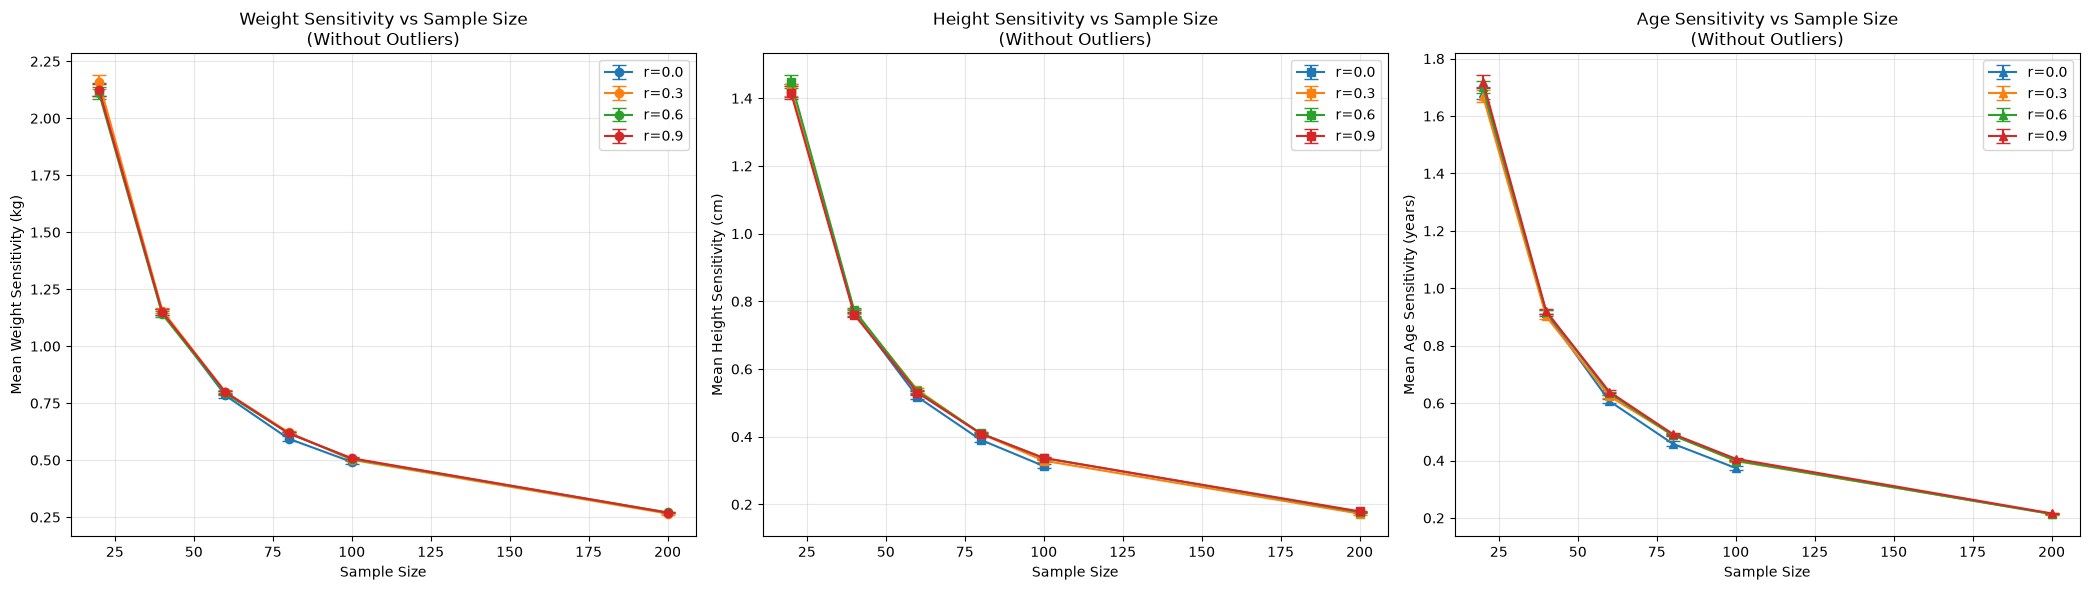

Preparing 3D plot with 4800 total Monte Carlo data points...
Sample size 20: 796 data points (expected: 800)
  - Weight sensitivity range: [1.1061, 3.6445]
  - Height sensitivity range: [0.7908, 2.2997]
  - Age sensitivity range: [0.8178, 2.7474]
  - Reconstruction error range: [39.1717, 120.7900]
Sample size 40: 731 data points (expected: 800)
  - Weight sensitivity range: [0.6752, 1.7815]
  - Height sensitivity range: [0.4217, 1.0928]
  - Age sensitivity range: [0.4868, 1.4066]
  - Reconstruction error range: [59.2773, 127.3235]
Sample size 60: 646 data points (expected: 800)
  - Weight sensitivity range: [0.5290, 1.1736]
  - Height sensitivity range: [0.3542, 0.8264]
  - Age sensitivity range: [0.4554, 0.8333]
  - Reconstruction error range: [70.2737, 125.7888]
Sample size 80: 575 data points (expected: 800)
  - Weight sensitivity range: [0.4405, 0.8525]
  - Height sensitivity range: [0.2959, 0.6359]
  - Age sensitivity range: [0.3440, 0.7045]
  - Reconstruction error range: [73.628

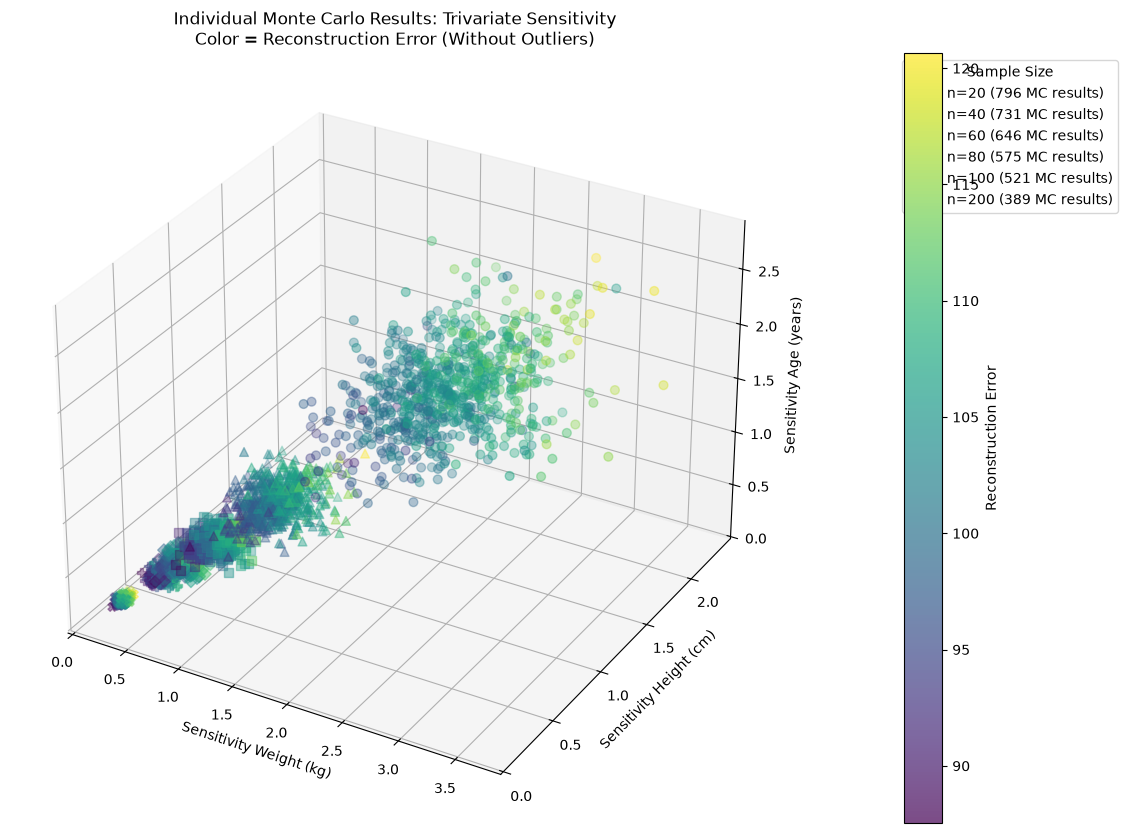

In [15]:
# Analyze sensitivity trends
sensitivity_analysis = []

for correlation in correlations:
    for sample_size in sample_sizes:

        # Filter successful runs without outliers
        subset = df_without[
            (df_without['correlation'] == correlation) &
            (df_without['sample_size'] == sample_size) &
            (df_without['dp_success'] == True)
        ]

        if len(subset) > 0:
            sensitivity_analysis.append({
                'correlation': correlation,
                'sample_size': sample_size,

                # Weight sensitivity
                'mean_sens_weight': subset['sensitivity_weight'].mean(),
                'std_sens_weight': subset['sensitivity_weight'].std(),
                'se_sens_weight': (
                    subset['sensitivity_weight'].std()
                    / np.sqrt(len(subset))
                ),

                # Height sensitivity
                'mean_sens_height': subset['sensitivity_height'].mean(),
                'std_sens_height': subset['sensitivity_height'].std(),
                'se_sens_height': (
                    subset['sensitivity_height'].std()
                    / np.sqrt(len(subset))
                ),

                # Age sensitivity
                'mean_sens_age': subset['sensitivity_age'].mean(),
                'std_sens_age': subset['sensitivity_age'].std(),
                'se_sens_age': (
                    subset['sensitivity_age'].std()
                    / np.sqrt(len(subset))
                ),

                # Reconstruction error
                'mean_recon_error': subset['reconstruction_error'].mean(),
                'std_recon_error': subset['reconstruction_error'].std(),

                'n_samples': len(subset)
            })

sens_df = pd.DataFrame(sensitivity_analysis)


# ============================================================
# Plot sensitivity trends
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(21, 6)
)


# ------------------------------------------------------------
# Plot 1: Weight sensitivity
# ------------------------------------------------------------

ax1 = axes[0]

for correlation in correlations:
    subset = sens_df[
        sens_df['correlation'] == correlation
    ]

    ax1.errorbar(
        subset['sample_size'],
        subset['mean_sens_weight'],
        yerr=subset['se_sens_weight'],
        fmt='o-',
        capsize=5,
        label=f'r={correlation}'
    )

ax1.set_xlabel('Sample Size')
ax1.set_ylabel('Mean Weight Sensitivity (kg)')
ax1.set_title(
    'Weight Sensitivity vs Sample Size\n'
    '(Without Outliers)'
)
ax1.legend()
ax1.grid(True, alpha=0.3)


# ------------------------------------------------------------
# Plot 2: Height sensitivity
# ------------------------------------------------------------

ax2 = axes[1]

for correlation in correlations:
    subset = sens_df[
        sens_df['correlation'] == correlation
    ]

    ax2.errorbar(
        subset['sample_size'],
        subset['mean_sens_height'],
        yerr=subset['se_sens_height'],
        fmt='s-',
        capsize=5,
        label=f'r={correlation}'
    )

ax2.set_xlabel('Sample Size')
ax2.set_ylabel('Mean Height Sensitivity (cm)')
ax2.set_title(
    'Height Sensitivity vs Sample Size\n'
    '(Without Outliers)'
)
ax2.legend()
ax2.grid(True, alpha=0.3)


# ------------------------------------------------------------
# Plot 3: Age sensitivity
# ------------------------------------------------------------

ax3 = axes[2]

for correlation in correlations:
    subset = sens_df[
        sens_df['correlation'] == correlation
    ]

    ax3.errorbar(
        subset['sample_size'],
        subset['mean_sens_age'],
        yerr=subset['se_sens_age'],
        fmt='^-',
        capsize=5,
        label=f'r={correlation}'
    )

ax3.set_xlabel('Sample Size')
ax3.set_ylabel('Mean Age Sensitivity (years)')
ax3.set_title(
    'Age Sensitivity vs Sample Size\n'
    '(Without Outliers)'
)
ax3.legend()
ax3.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()


# ============================================================
# 3D Plot:
# Weight × Height × Age sensitivity
#
# Reconstruction error is represented by COLOR
# ============================================================

print(
    f"Preparing 3D plot with "
    f"{len(df_without)} total Monte Carlo data points..."
)

fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(
    111,
    projection='3d'
)


# Only successful runs
successful = df_without[
    df_without['dp_success'] == True
]


# ------------------------------------------------------------
# Plot each sample size separately so sample size can
# still be represented by marker shape
# ------------------------------------------------------------

marker_map = {
    20: 'o',
    40: '^',
    60: 's',
    80: 'D',
    100: 'P',
    200: 'X'
}


scatter_for_colorbar = None

for sample_size in sample_sizes:

    subset = successful[
        successful['sample_size'] == sample_size
    ]

    if len(subset) > 0:

        expected_points = (
            n_mc_iterations
            * len(correlations)
        )

        print(
            f"Sample size {sample_size}: "
            f"{len(subset)} data points "
            f"(expected: {expected_points})"
        )

        # Extract all three sensitivity dimensions
        weight_sens = subset[
            'sensitivity_weight'
        ].values

        height_sens = subset[
            'sensitivity_height'
        ].values

        age_sens = subset[
            'sensitivity_age'
        ].values

        recon_error = subset[
            'reconstruction_error'
        ].values


        print(
            "  - Weight sensitivity range: "
            f"[{weight_sens.min():.4f}, "
            f"{weight_sens.max():.4f}]"
        )

        print(
            "  - Height sensitivity range: "
            f"[{height_sens.min():.4f}, "
            f"{height_sens.max():.4f}]"
        )

        print(
            "  - Age sensitivity range: "
            f"[{age_sens.min():.4f}, "
            f"{age_sens.max():.4f}]"
        )

        print(
            "  - Reconstruction error range: "
            f"[{recon_error.min():.4f}, "
            f"{recon_error.max():.4f}]"
        )


        scatter = ax.scatter(
            weight_sens,
            height_sens,
            age_sens,

            # Reconstruction error encoded as color
            c=recon_error,
            cmap='viridis',

            marker=marker_map.get(
                sample_size,
                'o'
            ),

            s=40,
            alpha=0.7,

            label=(
                f'n={sample_size} '
                f'({len(subset)} MC results)'
            )
        )

        scatter_for_colorbar = scatter


# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

ax.set_xlabel(
    "Sensitivity Weight (kg)"
)

ax.set_ylabel(
    "Sensitivity Height (cm)"
)

ax.set_zlabel(
    "Sensitivity Age (years)"
)


ax.set_title(
    "Individual Monte Carlo Results: "
    "Trivariate Sensitivity\n"
    "Color = Reconstruction Error "
    "(Without Outliers)"
)


# ------------------------------------------------------------
# Reconstruction-error color bar
# ------------------------------------------------------------

if scatter_for_colorbar is not None:
    cbar = fig.colorbar(
        scatter_for_colorbar,
        ax=ax,
        pad=0.1
    )

    cbar.set_label(
        'Reconstruction Error'
    )


ax.legend(
    title="Sample Size",
    bbox_to_anchor=(1.15, 1),
    loc='upper left'
)

plt.show()

### 2. Outlier Detection Analysis: Index-Based Approach 

If differential privacy is effective, index 0 should not show significantly higher detection rates than other indices.

- **Index 0**: Where the outlier was injected (should have similar detection rate if DP works)  
- **Other indices**: Normal observations (indices 1, 2, 3, ...)

Analyzing trivariate outlier detection with 95% confidence intervals...
Outlier detection considers Weight, Height, and Age.


Sample size 20:
  Expected trials: 800
  Actual trials: 762
  Successful DP: 762 / 800
    r= 0.0: 2/193 detected (1.0%)
    r= 0.3: 6/189 detected (3.2%)
    r= 0.6: 7/187 detected (3.7%)
    r= 0.9: 9/193 detected (4.7%)
  OVERALL injected-outlier detection: 24/762 (3.1%)
  Background false positives: 197/15920 observations (1.24%)

Sample size 40:
  Expected trials: 800
  Actual trials: 231
  Successful DP: 231 / 800
    r= 0.0: 0/31 detected (0.0%)
    r= 0.3: 0/20 detected (0.0%)
    r= 0.6: 0/47 detected (0.0%)
    r= 0.9: 1/133 detected (0.8%)
  OVERALL injected-outlier detection: 1/231 (0.4%)
  Background false positives: 4/29240 observations (0.01%)

Sample size 60:
  Expected trials: 800
  Actual trials: 174
  Successful DP: 174 / 800
    r= 0.3: 0/4 detected (0.0%)
    r= 0.6: 0/39 detected (0.0%)
    r= 0.9: 0/131 detected (0.0%)
  OVERALL injected-

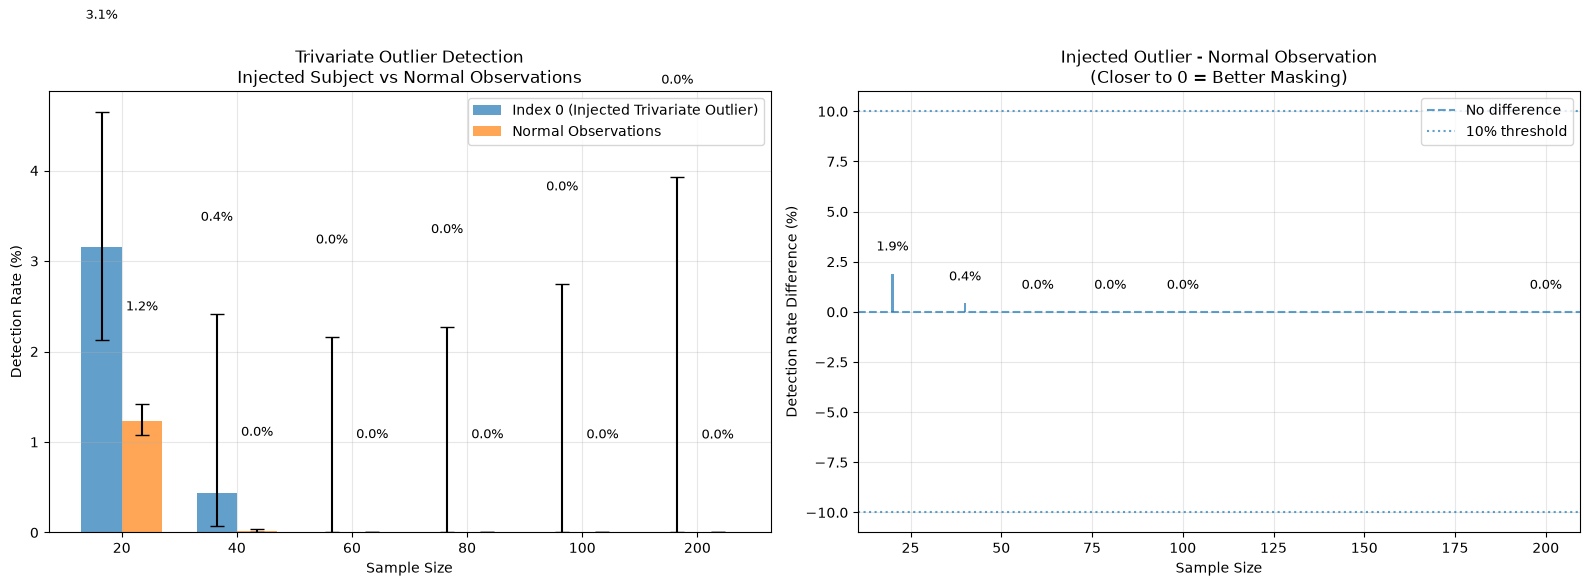


Summary:
- Total trials with injected outliers: 1562
- Total normal observations examined: 259820
- Average detection-rate difference: 0.4%
- Overall masking effectiveness: GOOD

Statistical Analysis:
- Size 20: Non-overlapping CIs (Injected: [2.1, 4.6]%, Normal: [1.1, 1.4]%)
- Size 40: Non-overlapping CIs (Injected: [0.1, 2.4]%, Normal: [0.0, 0.0]%)
- Size 60: Overlapping CIs (Injected: [0.0, 2.2]%, Normal: [0.0, 0.0]%)
- Size 80: Overlapping CIs (Injected: [0.0, 2.3]%, Normal: [0.0, 0.0]%)
- Size 100: Overlapping CIs (Injected: [0.0, 2.7]%, Normal: [0.0, 0.0]%)
- Size 200: Overlapping CIs (Injected: [0.0, 3.9]%, Normal: [0.0, 0.0]%)

Overall: 4/6 sample sizes show overlapping confidence intervals

Trivariate Outlier Detection Summary (With Injected Outliers):
Size   Correlation Detection Rate  N Samples 
-------------------------------------------------------
20.0   0.0         1.0            % 193.0     
20.0   0.3         3.2            % 189.0     
20.0   0.6         3.7         

In [16]:
# Trivariate Outlier Detection Analysis:
# Index-based comparison with confidence intervals

from scipy import stats


def binomial_confidence_interval(
    n_success,
    n_trials,
    confidence=0.95
):
    """
    Calculate binomial confidence interval using Wilson score interval.

    More robust than the normal approximation for small samples
    or extreme proportions.
    """

    if n_trials == 0:
        return 0.0, 0.0

    alpha = 1 - confidence
    z = stats.norm.ppf(1 - alpha / 2)

    p_hat = n_success / n_trials
    n = n_trials

    center = (
        p_hat + z**2 / (2 * n)
    ) / (
        1 + z**2 / n
    )

    width = (
        z
        * np.sqrt(
            (
                p_hat * (1 - p_hat)
                + z**2 / (4 * n)
            )
            / n
        )
        / (1 + z**2 / n)
    )

    lower = max(
        0,
        center - width
    )

    upper = min(
        1,
        center + width
    )

    return lower, upper


print(
    "Analyzing trivariate outlier detection "
    "with 95% confidence intervals..."
)

print(
    "Outlier detection considers Weight, Height, and Age.\n"
)


# ============================================================
# Detection analysis
# ============================================================

detection_by_sample_size = {}


for sample_size in sample_sizes:

    # --------------------------------------------------------
    # Runs WITH injected trivariate outlier
    # --------------------------------------------------------

    subset_with = df_with[
        (df_with['sample_size'] == sample_size)
        & (df_with['dp_success'] == True)
    ]

    if len(subset_with) > 0:

        expected_trials = (
            n_mc_iterations
            * len(correlations)
        )

        print(
            f"\nSample size {sample_size}:"
        )

        print(
            f"  Expected trials: "
            f"{expected_trials}"
        )

        print(
            f"  Actual trials: "
            f"{len(subset_with)}"
        )

        print(
            f"  Successful DP: "
            f"{len(subset_with)} / "
            f"{expected_trials}"
        )


        # ----------------------------------------------------
        # Detection by correlation
        # ----------------------------------------------------

        for correlation in correlations:

            corr_subset = subset_with[
                subset_with[
                    'correlation'
                ] == correlation
            ]

            if len(corr_subset) > 0:

                detections = (
                    corr_subset[
                        'noisy_outlier_detected'
                    ].sum()
                )

                trials = len(
                    corr_subset
                )

                print(
                    f"    r={correlation:4.1f}: "
                    f"{detections}/{trials} detected "
                    f"({100 * detections / trials:.1f}%)"
                )


        # ----------------------------------------------------
        # Detection of injected outlier at index 0
        #
        # This flag already represents:
        #
        # Weight OR Height OR Age
        # ----------------------------------------------------

        detection_rate_index_0 = (
            subset_with[
                'noisy_outlier_detected'
            ].mean()
        )

        n_detected_with = (
            subset_with[
                'noisy_outlier_detected'
            ].sum()
        )

        n_trials_with = len(
            subset_with
        )

        print(
            f"  OVERALL injected-outlier detection: "
            f"{n_detected_with}/{n_trials_with} "
            f"({100 * detection_rate_index_0:.1f}%)"
        )


        # Confidence interval for injected outlier
        ci_lower_idx0, ci_upper_idx0 = (
            binomial_confidence_interval(
                n_detected_with,
                n_trials_with
            )
        )


        # ====================================================
        # Background false-positive detection
        #
        # IMPORTANT:
        # noisy_outlier_detected cannot be used here because
        # your MC function sets it to False when
        # outlier_injected=False.
        #
        # Instead, use ALL detected normal observations.
        # ====================================================

        subset_without = df_without[
            (df_without['sample_size'] == sample_size)
            & (df_without['dp_success'] == True)
        ]

        if len(subset_without) > 0:

            expected_bg_trials = (
                n_mc_iterations
                * len(correlations)
            )

            # Total number of normal observations examined
            n_background_observations = (
                len(subset_without)
                * sample_size
            )

            # Total number flagged as outliers
            n_detected_without = (
                subset_without[
                    'noisy_total_outliers_detected'
                ].sum()
            )

            background_detection_rate = (
                n_detected_without
                / n_background_observations
            )

            print(
                f"  Background false positives: "
                f"{n_detected_without}/"
                f"{n_background_observations} observations "
                f"({100 * background_detection_rate:.2f}%)"
            )


            # Confidence interval for background rate
            ci_lower_bg, ci_upper_bg = (
                binomial_confidence_interval(
                    n_detected_without,
                    n_background_observations
                )
            )

        else:

            background_detection_rate = 0.0

            n_background_observations = 0
            n_detected_without = 0

            ci_lower_bg = 0.0
            ci_upper_bg = 0.0

            print(
                "  Background: No successful trials"
            )


        # ----------------------------------------------------
        # Store results
        # ----------------------------------------------------

        detection_by_sample_size[
            sample_size
        ] = {

            # Injected trivariate outlier
            'index_0_detection':
                detection_rate_index_0,

            # Background false positives among
            # normal observations
            'other_indices_avg':
                background_detection_rate,

            'n_trials_with':
                n_trials_with,

            'n_background_observations':
                n_background_observations,

            'n_detected_with':
                n_detected_with,

            'n_detected_without':
                n_detected_without,

            # Confidence intervals
            'ci_lower_idx0':
                ci_lower_idx0,

            'ci_upper_idx0':
                ci_upper_idx0,

            'ci_lower_bg':
                ci_lower_bg,

            'ci_upper_bg':
                ci_upper_bg,

            # Difference between detecting the injected
            # trivariate outlier and a normal observation
            'dp_effectiveness':
                abs(
                    detection_rate_index_0
                    - background_detection_rate
                )
        }


# ============================================================
# Display results
# ============================================================

print(
    "\nTrivariate Detection Rate Comparison:"
)

print(
    "Injected Index 0 vs Normal Observations"
)

print("=" * 90)

print(
    f"{'Size':<6} "
    f"{'Index 0':<22} "
    f"{'Normal Obs.':<22} "
    f"{'Difference':<12} "
    f"{'DP Effect':<12}"
)

print(
    f"{'':6} "
    f"{'Rate [95% CI]':<22} "
    f"{'Rate [95% CI]':<22} "
    f"{'(%)':<12}"
)

print("-" * 90)


for sample_size in sample_sizes:

    if sample_size in detection_by_sample_size:

        data = detection_by_sample_size[
            sample_size
        ]

        idx0_rate = (
            data[
                'index_0_detection'
            ]
            * 100
        )

        others_rate = (
            data[
                'other_indices_avg'
            ]
            * 100
        )

        diff = (
            idx0_rate
            - others_rate
        )


        idx0_ci = (
            f"["
            f"{data['ci_lower_idx0'] * 100:.1f}, "
            f"{data['ci_upper_idx0'] * 100:.1f}"
            f"]"
        )

        bg_ci = (
            f"["
            f"{data['ci_lower_bg'] * 100:.1f}, "
            f"{data['ci_upper_bg'] * 100:.1f}"
            f"]"
        )


        # Smaller difference means better masking
        effectiveness = (
            "GOOD"
            if abs(diff) < 10
            else "WEAK"
            if abs(diff) < 20
            else "POOR"
        )


        print(
            f"{sample_size:<6} "
            f"{idx0_rate:5.1f} "
            f"{idx0_ci:<15} "
            f"{others_rate:5.1f} "
            f"{bg_ci:<15} "
            f"{diff:<12.1f} "
            f"{effectiveness:<12}"
        )


print("\nInterpretation:")

print(
    "- Index 0: detection rate of the injected "
    "Weight/Height/Age outlier"
)

print(
    "- Normal Obs.: false-positive detection rate "
    "among observations with no injected outlier"
)

print(
    "- [95% CI]: Wilson score confidence intervals"
)

print(
    "- Difference: how much the injected subject "
    "stands out"
)

print(
    "- Smaller difference = stronger masking"
)


# ============================================================
# Plot comparison with confidence intervals
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)


sample_sizes_plot = list(
    detection_by_sample_size.keys()
)


index_0_rates = [
    detection_by_sample_size[s][
        'index_0_detection'
    ] * 100

    for s in sample_sizes_plot
]


other_rates = [
    detection_by_sample_size[s][
        'other_indices_avg'
    ] * 100

    for s in sample_sizes_plot
]


# ------------------------------------------------------------
# Confidence interval error bars
# ------------------------------------------------------------

idx0_errors_lower = [

    max(
        0,
        detection_by_sample_size[s][
            'index_0_detection'
        ] * 100
        -
        detection_by_sample_size[s][
            'ci_lower_idx0'
        ] * 100
    )

    for s in sample_sizes_plot
]


idx0_errors_upper = [

    detection_by_sample_size[s][
        'ci_upper_idx0'
    ] * 100
    -
    detection_by_sample_size[s][
        'index_0_detection'
    ] * 100

    for s in sample_sizes_plot
]


bg_errors_lower = [

    max(
        0,
        detection_by_sample_size[s][
            'other_indices_avg'
        ] * 100
        -
        detection_by_sample_size[s][
            'ci_lower_bg'
        ] * 100
    )

    for s in sample_sizes_plot
]


bg_errors_upper = [

    detection_by_sample_size[s][
        'ci_upper_bg'
    ] * 100
    -
    detection_by_sample_size[s][
        'other_indices_avg'
    ] * 100

    for s in sample_sizes_plot
]


x = np.arange(
    len(sample_sizes_plot)
)

width = 0.35


# ------------------------------------------------------------
# Plot 1: Detection rates
# ------------------------------------------------------------

bars1 = ax1.bar(

    x - width / 2,

    index_0_rates,

    width,

    label=(
        'Index 0 '
        '(Injected Trivariate Outlier)'
    ),

    alpha=0.7,

    yerr=[
        idx0_errors_lower,
        idx0_errors_upper
    ],

    capsize=5
)


bars2 = ax1.bar(

    x + width / 2,

    other_rates,

    width,

    label='Normal Observations',

    alpha=0.7,

    yerr=[
        bg_errors_lower,
        bg_errors_upper
    ],

    capsize=5
)


ax1.set_xlabel(
    'Sample Size'
)

ax1.set_ylabel(
    'Detection Rate (%)'
)

ax1.set_title(
    'Trivariate Outlier Detection\n'
    'Injected Subject vs Normal Observations'
)

ax1.set_xticks(
    x
)

ax1.set_xticklabels(
    sample_sizes_plot
)

ax1.legend()

ax1.grid(
    True,
    alpha=0.3
)


# Value labels
for i, (bar, rate) in enumerate(
    zip(
        bars1,
        index_0_rates
    )
):

    ci_upper = (
        detection_by_sample_size[
            sample_sizes_plot[i]
        ][
            'ci_upper_idx0'
        ]
        * 100
    )

    ax1.text(
        bar.get_x()
        + bar.get_width() / 2,
        ci_upper + 1,

        f'{rate:.1f}%',

        ha='center',
        va='bottom',
        fontsize=9
    )


for i, (bar, rate) in enumerate(
    zip(
        bars2,
        other_rates
    )
):

    ci_upper = (
        detection_by_sample_size[
            sample_sizes_plot[i]
        ][
            'ci_upper_bg'
        ]
        * 100
    )

    ax1.text(
        bar.get_x()
        + bar.get_width() / 2,
        ci_upper + 1,

        f'{rate:.1f}%',

        ha='center',
        va='bottom',
        fontsize=9
    )


# ------------------------------------------------------------
# Plot 2: Detection-rate difference
# ------------------------------------------------------------

differences = [

    idx - oth

    for idx, oth
    in zip(
        index_0_rates,
        other_rates
    )
]


bars3 = ax2.bar(
    sample_sizes_plot,
    differences,
    alpha=0.7
)


ax2.set_xlabel(
    'Sample Size'
)

ax2.set_ylabel(
    'Detection Rate Difference (%)'
)

ax2.set_title(
    'Injected Outlier - Normal Observation\n'
    '(Closer to 0 = Better Masking)'
)


ax2.axhline(
    y=0,
    linestyle='--',
    alpha=0.7,
    label='No difference'
)

ax2.axhline(
    y=10,
    linestyle=':',
    alpha=0.7,
    label='10% threshold'
)

ax2.axhline(
    y=-10,
    linestyle=':',
    alpha=0.7
)

ax2.legend()

ax2.grid(
    True,
    alpha=0.3
)


for bar, diff in zip(
    bars3,
    differences
):

    height = bar.get_height()

    y_pos = (
        height + 1
        if height >= 0
        else height - 2
    )

    ax2.text(

        bar.get_x()
        + bar.get_width() / 2,

        y_pos,

        f'{diff:.1f}%',

        ha='center',

        va=(
            'bottom'
            if height >= 0
            else 'top'
        ),

        fontsize=9
    )


plt.tight_layout()
plt.show()


# ============================================================
# Summary
# ============================================================

print("\nSummary:")


total_trials_with = sum(
    data['n_trials_with']
    for data in detection_by_sample_size.values()
)

total_background_observations = sum(
    data['n_background_observations']
    for data in detection_by_sample_size.values()
)

print(f"- Total trials with injected outliers: {total_trials_with}")
print(f"- Total normal observations examined: {total_background_observations}")


avg_difference = np.mean([

    abs(
        detection_by_sample_size[s][
            'index_0_detection'
        ]
        -
        detection_by_sample_size[s][
            'other_indices_avg'
        ]
    )
    * 100

    for s in sample_sizes

    if s in detection_by_sample_size
])


print(
    f"- Average detection-rate difference: "
    f"{avg_difference:.1f}%"
)


if avg_difference < 10:

    print(
        "- Overall masking effectiveness: GOOD"
    )

elif avg_difference < 20:

    print(
        "- Overall masking effectiveness: WEAK"
    )

else:

    print(
        "- Overall masking effectiveness: POOR"
    )


# ============================================================
# Confidence interval comparison
# ============================================================

print("\nStatistical Analysis:")

overlapping_cis = 0
non_overlapping_cis = 0


for sample_size in sample_sizes_plot:

    data = detection_by_sample_size[
        sample_size
    ]

    idx0_lower = (
        data['ci_lower_idx0']
        * 100
    )

    idx0_upper = (
        data['ci_upper_idx0']
        * 100
    )

    bg_lower = (
        data['ci_lower_bg']
        * 100
    )

    bg_upper = (
        data['ci_upper_bg']
        * 100
    )


    overlap = (
        max(
            idx0_lower,
            bg_lower
        )
        <
        min(
            idx0_upper,
            bg_upper
        )
    )


    if overlap:

        overlapping_cis += 1

    else:

        non_overlapping_cis += 1


    print(
        f"- Size {sample_size}: "
        f"{'Overlapping CIs' if overlap else 'Non-overlapping CIs'} "
        f"(Injected: "
        f"[{idx0_lower:.1f}, {idx0_upper:.1f}]%, "
        f"Normal: "
        f"[{bg_lower:.1f}, {bg_upper:.1f}]%)"
    )


print(
    f"\nOverall: "
    f"{overlapping_cis}/"
    f"{len(sample_sizes_plot)} "
    "sample sizes show overlapping confidence intervals"
)


# ============================================================
# Outlier detection summary by sample size and correlation
# ============================================================

print(
    "\nTrivariate Outlier Detection Summary "
    "(With Injected Outliers):"
)

print("=" * 55)

print(
    f"{'Size':<6} "
    f"{'Correlation':<11} "
    f"{'Detection Rate':<15} "
    f"{'N Samples':<10}"
)

print("-" * 55)



outlier_summary = []

for sample_size in sample_sizes:
    for correlation in correlations:

        subset = df_with[
            (df_with['sample_size'] == sample_size) &
            (df_with['correlation'] == correlation) &
            (df_with['dp_success'] == True)
        ]

        if len(subset) > 0:
            outlier_summary.append({
                'sample_size': sample_size,
                'correlation': correlation,
                'detection_rate': (
                    subset['noisy_outlier_detected'].mean() * 100
                ),
                'n_samples': len(subset)
            })

outlier_df = pd.DataFrame(outlier_summary)


for _, row in outlier_df.iterrows():

    print(
        f"{row['sample_size']:<6} "
        f"{row['correlation']:<11.1f} "
        f"{row['detection_rate']:<15.1f}% "
        f"{row['n_samples']:<10}"
    )


avg_detection = (
    outlier_df[
        'detection_rate'
    ].mean()
)


print("\nKey Findings:")

print(
    "Average trivariate outlier detection rate "
    f"WITH injected outlier: "
    f"{avg_detection:.2f}%"
)


best_detection = outlier_df.loc[
    outlier_df[
        'detection_rate'
    ].idxmax()
]

worst_detection = outlier_df.loc[
    outlier_df[
        'detection_rate'
    ].idxmin()
]


print(
    "\nBest detection: "
    f"{best_detection['detection_rate']:.1f}% "
    f"(size={best_detection['sample_size']}, "
    f"r={best_detection['correlation']})"
)

print(
    "Worst detection: "
    f"{worst_detection['detection_rate']:.1f}% "
    f"(size={worst_detection['sample_size']}, "
    f"r={worst_detection['correlation']})"
)


🔍 RECONSTRUCTED DATA OUTLIER DETECTION ANALYSIS
Testing: Can reconstruction identify the injected outlier at index 0?
Good DP: Index 0 detection ≈ background detection (outlier remains hidden)
Poor DP: Index 0 detection >> background detection (outlier is exposed)

Analyzing reconstruction-based outlier detection by sample size...
Following the same approach: comparing index 0 (outlier) vs background detection


Sample size 20 (RECONSTRUCTED DATA):
  Expected trials: 800 (10 MC × 4 correlations)
  Actual trials: 762
  Successful DP: 762 / 800
    r= 0.0: 2/193 detected (1.0%)
    r= 0.3: 6/189 detected (3.2%)
    r= 0.6: 7/187 detected (3.7%)
    r= 0.9: 9/193 detected (4.7%)
  OVERALL: 24/762 detected (3.1%)
  Background (no outlier): 0/796 detected (0.0%)

Sample size 40 (RECONSTRUCTED DATA):
  Expected trials: 800 (10 MC × 4 correlations)
  Actual trials: 231
  Successful DP: 231 / 800
    r= 0.0: 0/31 detected (0.0%)
    r= 0.3: 0/20 detected (0.0%)
    r= 0.6: 0/47 detected (0.0%

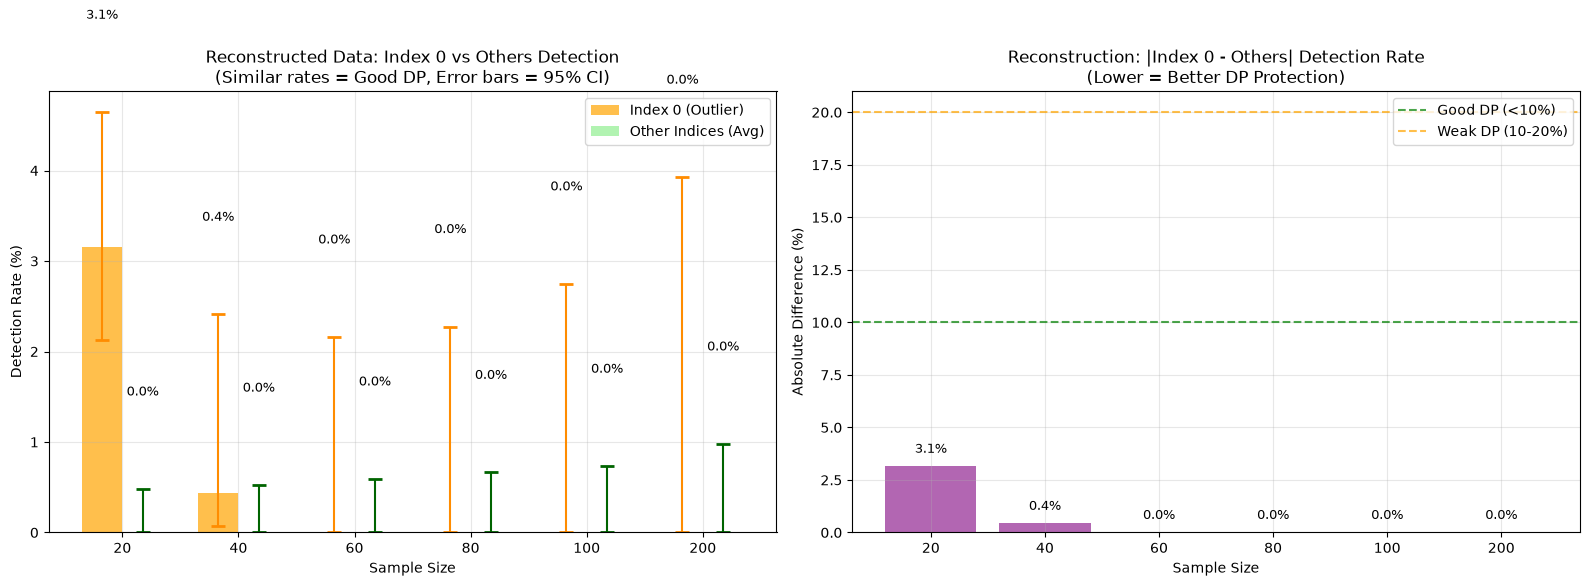


📊 COMPARISON: NOISY vs RECONSTRUCTED DATA DETECTION
Sample Noisy Index0 Recons Index0 Noisy BG   Recons BG   Protection  
Size   Rate (%)     Rate (%)      Rate (%)   Rate (%)    Quality     
--------------------------------------------------------------------------------
20     3.1          3.1           1.2        0.0         EXCELLENT   
40     0.4          0.4           0.0        0.0         EXCELLENT   
60     0.0          0.0           0.0        0.0         EXCELLENT   
80     0.0          0.0           0.0        0.0         EXCELLENT   
100    0.0          0.0           0.0        0.0         EXCELLENT   
200    0.0          0.0           0.0        0.0         EXCELLENT   

🎯 KEY INSIGHTS:
• Low detection rates (≤10%) = Strong DP protection
• Similar rates for Index 0 vs Background = Outlier successfully hidden
• Reconstruction rates ≈ Noisy rates = Consistent protection across pipeline
• High differences = DP may need stronger privacy parameters


In [17]:
# Analysis of Reconstructed Data Outlier Detection
# The reconstruction process uses leave-one-out (LOO) analysis to try to recover original data
# If DP works properly, reconstruction should NOT be able to identify index 0 (outlier) 
# more than any other indices - this tests the effectiveness of DP protection

print("\n" + "="*80)
print("🔍 RECONSTRUCTED DATA OUTLIER DETECTION ANALYSIS")
print("="*80)
print("Testing: Can reconstruction identify the injected outlier at index 0?")
print("Good DP: Index 0 detection ≈ background detection (outlier remains hidden)")
print("Poor DP: Index 0 detection >> background detection (outlier is exposed)")

# Wilson score confidence interval for binomial proportions
def binomial_confidence_interval(successes, trials, confidence=0.95):
    if trials == 0:
        return 0.0, 0.0
    
    p = successes / trials
    z = 1.96  # For 95% confidence
    
    denominator = 1 + z**2/trials
    center = (p + z**2/(2*trials)) / denominator
    margin = z * np.sqrt(p*(1-p)/trials + z**2/(4*trials**2)) / denominator
    
    return max(0, center - margin), min(1, center + margin)

print("\nAnalyzing reconstruction-based outlier detection by sample size...")
print("Following the same approach: comparing index 0 (outlier) vs background detection\n")

detection_by_sample_size_recons = {}

for sample_size in sample_sizes:
    # Get data with outliers for this sample size (aggregating across ALL correlations)
    subset_with = df_with[(df_with['sample_size'] == sample_size) & 
                         (df_with['dp_success'] == True)]
    
    if len(subset_with) > 0:
        # Debug: Check data aggregation for reconstructed data
        expected_trials = n_mc_iterations * len(correlations)  # 10 MC × 5 correlations = 50
        print(f"\nSample size {sample_size} (RECONSTRUCTED DATA):")
        print(f"  Expected trials: {expected_trials} (10 MC × {len(correlations)} correlations)")
        print(f"  Actual trials: {len(subset_with)}")
        print(f"  Successful DP: {len(subset_with)} / {expected_trials}")
        
        # Check reconstruction detection breakdown by correlation
        for correlation in correlations:
            corr_subset = subset_with[subset_with['correlation'] == correlation]
            if len(corr_subset) > 0:
                detections = corr_subset['recons_outlier_detected'].sum()
                trials = len(corr_subset)
                print(f"    r={correlation:4.1f}: {detections}/{trials} detected ({100*detections/trials:.1f}%)")
        
        # Overall detection rate for this sample size (across all correlations)
        detection_rate_index_0 = subset_with['recons_outlier_detected'].mean()
        n_detected_with = subset_with['recons_outlier_detected'].sum()
        n_trials_with = len(subset_with)
        
        print(f"  OVERALL: {n_detected_with}/{n_trials_with} detected ({100*detection_rate_index_0:.1f}%)")
        
        # Calculate confidence interval for index 0 detection rate
        ci_lower_idx0, ci_upper_idx0 = binomial_confidence_interval(n_detected_with, n_trials_with)
        
        # For comparison with other indices, we use the detection rate from scenarios WITHOUT outliers
        # This represents the "background" detection rate for normal observations
        subset_without = df_without[(df_without['sample_size'] == sample_size) & 
                                   (df_without['dp_success'] == True)]
        
        if len(subset_without) > 0:
            # Debug: Check background detection for reconstructed data
            expected_bg_trials = n_mc_iterations * len(correlations)  # 10 MC × 5 correlations = 50
            bg_detections = subset_without['recons_outlier_detected'].sum()
            bg_trials = len(subset_without)
            print(f"  Background (no outlier): {bg_detections}/{bg_trials} detected ({100*bg_detections/bg_trials:.1f}%)")
            
            # In scenarios without injected outliers, any detection is "false positive"
            background_detection_rate = subset_without['recons_outlier_detected'].mean()
            n_detected_without = subset_without['recons_outlier_detected'].sum()
            n_trials_without = len(subset_without)
            
            # Calculate confidence interval for background detection rate
            ci_lower_bg, ci_upper_bg = binomial_confidence_interval(n_detected_without, n_trials_without)
        else:
            background_detection_rate = 0.0
            n_trials_without = 0
            ci_lower_bg, ci_upper_bg = 0.0, 0.0
            print(f"  Background: No successful trials")
        
        detection_by_sample_size_recons[sample_size] = {
            'index_0_detection': detection_rate_index_0,  # Where outlier was injected
            'other_indices_avg': background_detection_rate,  # Background rate  
            'n_trials_with': n_trials_with,
            'n_trials_without': n_trials_without,
            'n_detected_with': n_detected_with,
            'n_detected_without': n_detected_without,
            'ci_lower_idx0': ci_lower_idx0,
            'ci_upper_idx0': ci_upper_idx0,
            'ci_lower_bg': ci_lower_bg,
            'ci_upper_bg': ci_upper_bg,
            'dp_effectiveness': abs(detection_rate_index_0 - background_detection_rate)
        }

# Display results for reconstructed data with confidence intervals
print("\n" + "="*85)
print("RECONSTRUCTED DATA: Detection Rate Comparison")
print("="*85)
print(f"{'Size':<6} {'Index 0':<20} {'Others Avg':<20} {'Difference':<12} {'DP Effect':<12}")
print(f"{'':6} {'Rate [95% CI]':<20} {'Rate [95% CI]':<20} {'(%)':<12} {'':<12}")
print("-" * 85)

for sample_size in sample_sizes:
    if sample_size in detection_by_sample_size_recons:
        data = detection_by_sample_size_recons[sample_size]
        idx0_rate = data['index_0_detection'] * 100
        others_rate = data['other_indices_avg'] * 100
        diff = idx0_rate - others_rate
        
        # Format confidence intervals
        idx0_ci = f"[{data['ci_lower_idx0']*100:.1f}, {data['ci_upper_idx0']*100:.1f}]"
        bg_ci = f"[{data['ci_lower_bg']*100:.1f}, {data['ci_upper_bg']*100:.1f}]"
        
        # DP is effective if difference is small
        effectiveness = "GOOD" if abs(diff) < 10 else "WEAK" if abs(diff) < 20 else "POOR"
        
        print(f"{sample_size:<6} {idx0_rate:5.1f} {idx0_ci:<13} {others_rate:5.1f} {bg_ci:<13} {diff:<12.1f} {effectiveness:<12}")

print("\n🎯 INTERPRETATION (Reconstructed Data):")
print("- Index 0: Detection rate where outlier was injected")
print("- Others Avg: Background detection rate for normal observations")  
print("- [95% CI]: Wilson score confidence intervals")
print("- Difference: How much index 0 stands out after reconstruction")
print("- DP Effect: GOOD (<10%) = DP successfully hides outlier even from reconstruction")
print("           WEAK (10-20%) = Some outlier leakage in reconstruction")
print("           POOR (>20%) = Reconstruction easily finds the outlier")

# Plot comparison for reconstructed data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Detection rates comparison with error bars
sample_sizes_plot = list(detection_by_sample_size_recons.keys())
index_0_rates = [detection_by_sample_size_recons[s]['index_0_detection'] * 100 for s in sample_sizes_plot]
other_rates = [detection_by_sample_size_recons[s]['other_indices_avg'] * 100 for s in sample_sizes_plot]

# Calculate error bars (distance from mean to CI bounds, ensuring no negative values)
idx0_errors_lower = [max(0, detection_by_sample_size_recons[s]['index_0_detection'] * 100 - 
                         detection_by_sample_size_recons[s]['ci_lower_idx0'] * 100) for s in sample_sizes_plot]
idx0_errors_upper = [detection_by_sample_size_recons[s]['ci_upper_idx0'] * 100 - 
                     detection_by_sample_size_recons[s]['index_0_detection'] * 100 for s in sample_sizes_plot]

bg_errors_lower = [max(0, detection_by_sample_size_recons[s]['other_indices_avg'] * 100 - 
                       detection_by_sample_size_recons[s]['ci_lower_bg'] * 100) for s in sample_sizes_plot]
bg_errors_upper = [detection_by_sample_size_recons[s]['ci_upper_bg'] * 100 - 
                   detection_by_sample_size_recons[s]['other_indices_avg'] * 100 for s in sample_sizes_plot]

x = np.arange(len(sample_sizes_plot))
width = 0.35

# Create bars with error bars
bars1 = ax1.bar(x - width/2, index_0_rates, width, label='Index 0 (Outlier)', 
                color='orange', alpha=0.7,
                yerr=[idx0_errors_lower, idx0_errors_upper], 
                capsize=5, error_kw={'ecolor': 'darkorange', 'capthick': 2})

bars2 = ax1.bar(x + width/2, other_rates, width, label='Other Indices (Avg)', 
                color='lightgreen', alpha=0.7,
                yerr=[bg_errors_lower, bg_errors_upper], 
                capsize=5, error_kw={'ecolor': 'darkgreen', 'capthick': 2})

ax1.set_xlabel('Sample Size')
ax1.set_ylabel('Detection Rate (%)')
ax1.set_title('Reconstructed Data: Index 0 vs Others Detection\n(Similar rates = Good DP, Error bars = 95% CI)')
ax1.set_xticks(x)
ax1.set_xticklabels(sample_sizes_plot)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for i, (bar, rate) in enumerate(zip(bars1, index_0_rates)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + idx0_errors_upper[i] + 1,
             f'{rate:.1f}%', ha='center', va='bottom', fontsize=9)

for i, (bar, rate) in enumerate(zip(bars2, other_rates)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + bg_errors_upper[i] + 1,
             f'{rate:.1f}%', ha='center', va='bottom', fontsize=9)

# Plot 2: Difference between index 0 and others (smaller is better for DP)
differences = [abs(idx0 - others) for idx0, others in zip(index_0_rates, other_rates)]
bars3 = ax2.bar(x, differences, color='purple', alpha=0.6)

ax2.set_xlabel('Sample Size')
ax2.set_ylabel('Absolute Difference (%)')
ax2.set_title('Reconstruction: |Index 0 - Others| Detection Rate\n(Lower = Better DP Protection)')
ax2.set_xticks(x)
ax2.set_xticklabels(sample_sizes_plot)
ax2.grid(True, alpha=0.3)

# Add horizontal lines for interpretation
ax2.axhline(y=10, color='green', linestyle='--', alpha=0.7, label='Good DP (<10%)')
ax2.axhline(y=20, color='orange', linestyle='--', alpha=0.7, label='Weak DP (10-20%)')
ax2.legend()

# Add value labels
for bar, diff in zip(bars3, differences):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{diff:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Summary comparison between noisy and reconstructed detection
print("\n" + "="*80)
print("📊 COMPARISON: NOISY vs RECONSTRUCTED DATA DETECTION")
print("="*80)
print(f"{'Sample':<6} {'Noisy Index0':<12} {'Recons Index0':<13} {'Noisy BG':<10} {'Recons BG':<11} {'Protection':<12}")
print(f"{'Size':<6} {'Rate (%)':<12} {'Rate (%)':<13} {'Rate (%)':<10} {'Rate (%)':<11} {'Quality':<12}")
print("-" * 80)

for sample_size in sample_sizes:
    if sample_size in detection_by_sample_size and sample_size in detection_by_sample_size_recons:
        noisy_idx0 = detection_by_sample_size[sample_size]['index_0_detection'] * 100
        recons_idx0 = detection_by_sample_size_recons[sample_size]['index_0_detection'] * 100
        noisy_bg = detection_by_sample_size[sample_size]['other_indices_avg'] * 100
        recons_bg = detection_by_sample_size_recons[sample_size]['other_indices_avg'] * 100
        
        # Assess overall protection quality
        max_diff = max(abs(noisy_idx0 - noisy_bg), abs(recons_idx0 - recons_bg))
        protection = "EXCELLENT" if max_diff < 5 else "GOOD" if max_diff < 10 else "WEAK" if max_diff < 20 else "POOR"
        
        print(f"{sample_size:<6} {noisy_idx0:<12.1f} {recons_idx0:<13.1f} {noisy_bg:<10.1f} {recons_bg:<11.1f} {protection:<12}")

print("\n🎯 KEY INSIGHTS:")
print("• Low detection rates (≤10%) = Strong DP protection")
print("• Similar rates for Index 0 vs Background = Outlier successfully hidden")
print("• Reconstruction rates ≈ Noisy rates = Consistent protection across pipeline")
print("• High differences = DP may need stronger privacy parameters")